# T/NK Cell Figures
## Sid Gurajala

In [14]:
# library(Seurat)
# library(dplyr) 
# library(tidyr)
# library(viridis)
# library(pheatmap)
# library(presto)
# library(pals)
library(parallel)
# library(harmony)
# library(cowplot)
# library(singlecellmethods)
# library(ggplot2)
# library(lisi) 
# library(ggbeeswarm)

In [19]:
library(patchwork)
library(purrr)
library(dplyr) 
library(tidyr)
library(cowplot)
library(singlecellmethods)
library(ggplot2)
library(ggbeeswarm)

source("/data/srlab/anathan/scripts/scseq_utils.R")

In [3]:
# library(Seurat)
# library(viridis)
# library(pheatmap)
# library(presto)
# library(pals)
# library(harmony)
# library(lisi) 


In [4]:
# source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils.r")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: viridisLite

Loading required package: Rcpp



ERROR: Error in library(pals): there is no package called ‘pals’


In [7]:
clinical <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/clinical_data_05042023.rds') %>% 
                        rename(Final_Site = Site) %>% select(-sample)

# T_NK

In [4]:
qcd_meta <-readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')
qcd_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_norm_08112024.rds')
qcd_norm <- qcd_norm[, qcd_meta$cell]
#wilcox <- wilcoxauc(qcd_norm, qcd_meta$new_cluster_number)

In [3]:
# saveRDS(qcd_norm, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_norm_08112024.rds')

In [22]:
sn_control <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_control)
sn_LN <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_LN)
sc_control <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_control)
sc_LN <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_LN)
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"

In [26]:
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"

Joining, by = "new_cluster_number"
Joining, by = "new_cluster_number"
Joining, by = "new_cluster_number"


In [30]:
write.csv(merged, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/tnk_summary_04152024.csv', quote = FALSE, row.names = FALSE)

## Fine Grain Cell Types Figure 

### Single Cell UMAP, Single Nuclear UMAP

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


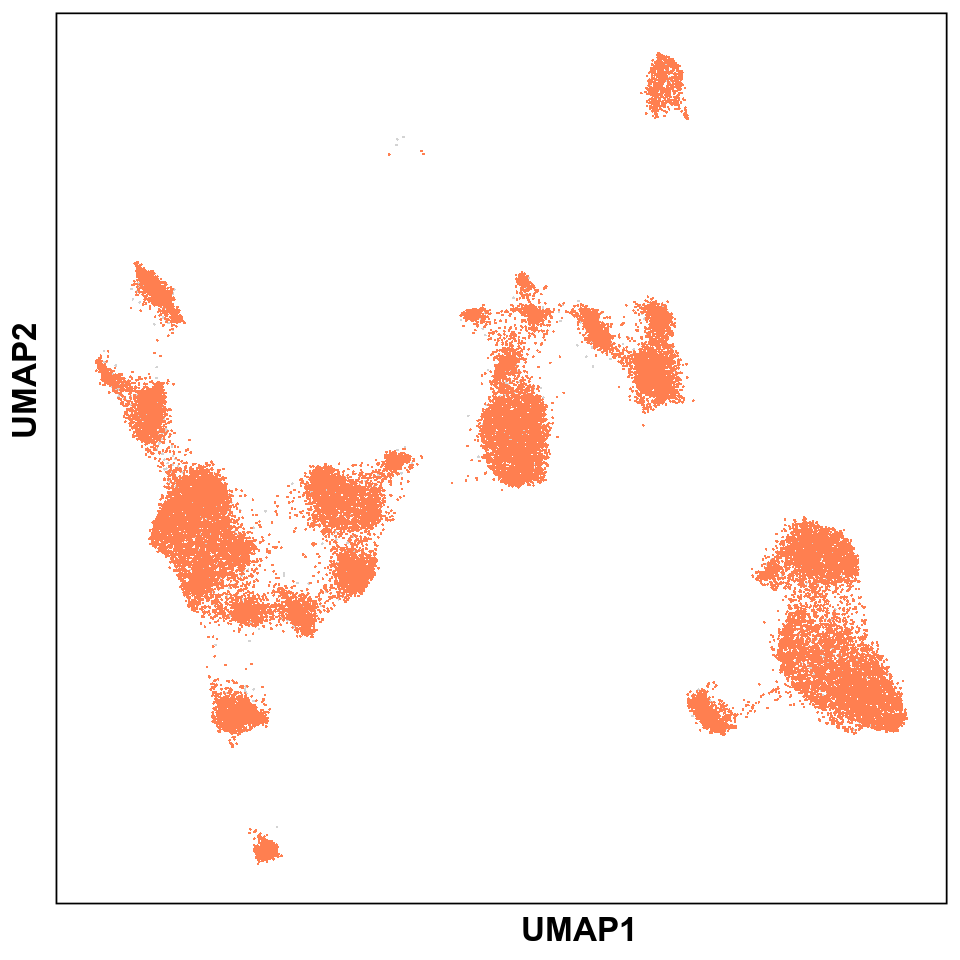

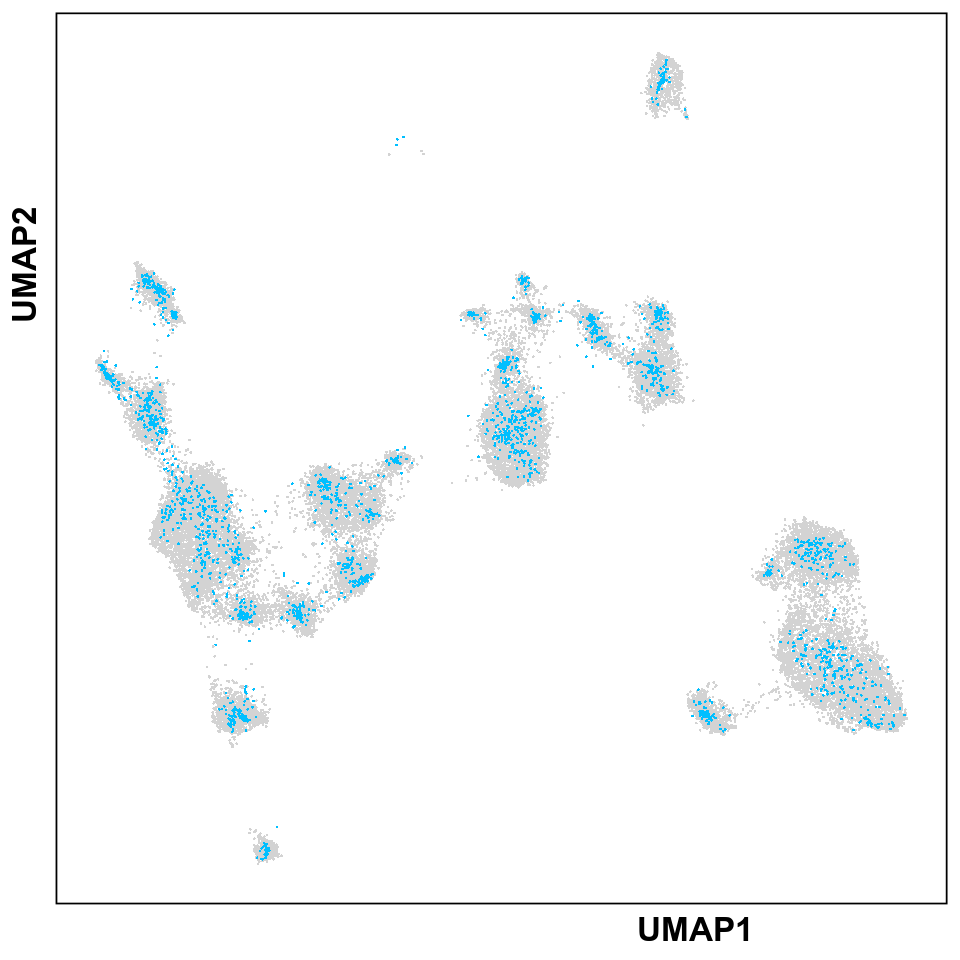

In [3]:
options(repr.plot.height = 8, repr.plot.width = 8)
ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "scRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "coral"
  ) +
theme_classic(base_size = 15) +
  theme(
    legend.position = "none",
        #  plot.title = element_text(hjust = 0.5, 
        #                            size = 18, 
        #                            face = "bold"),
          axis.title = element_text(hjust = 0.6, 
                                    size = 20, 
                                    face = "bold"), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1)
) +     labs(x = "UMAP1", y = "UMAP2") 


ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "snRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "deepskyblue"
  ) +
theme_classic(base_size = 15) +
  theme(
    legend.position = "none",
        #  plot.title = element_text(hjust = 0.5, 
        #                            size = 18, 
        #                            face = "bold"),
          axis.title = element_text(hjust = 0.75, 
                                    size = 20, 
                                    face = "bold"), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1)
) +     labs(x = "UMAP1", y = "UMAP2") 

### Cluster UMAPs

In [18]:
qcd_meta <- qcd_meta %>% filter(new_cluster_number != 12)

In [19]:
qcd_meta <- qcd_meta %>% mutate(new_cluster_number = ifelse(new_cluster_number > 12, new_cluster_number - 1, new_cluster_number))

In [81]:
final_annotation = data.frame(new_cluster_number = seq(0, 21), 
                               final_annotation = c("NK0. CD56dim NK",
                                             "T1. CD8+ GZMBhigh GZMHhigh CTL",
                                             "T2. CD8+ GZMBlow GZMHhigh CTL",
                                             "NK3. CD56bright NK",
                                             "T4. CENPF+ MKI67+ Proliferating",
                                             "T5. GZMK+ CD8+ CCL5high",
                                             "T6. GZMK+ CD8+ CCL5low",
                                             "T7. GZMK+ CD8+ Effector Memory",
                                             "T8. GZMK+ CD8+ NEAT1+",
                                             "T9. GZMK+ CD8+ Resident Memory",
                                             "T10. GZMK+ CD8+ ITGAE+ ITGA1+",
                                             "T11. CD4+ Effector Memory",
                                             "T12. CD8+ GMZK+ CD69+",
                                             "T13. CD4+ JUNlow Resident Memory",
                                             "T14. CD4+ JUNhigh Resident Memory",
                                             "T15. CD4+ S1PR1+ Central memory/Naive",
                                             "T16. KLRB1+ KIT+ ILC",
                                             "T17. CD4+ RORC+ CCR6+ Th17",
                                             "T18. CD4+ Central Memory/Naive",
                                             "T19. CD4+ IL2RA++ FOXP3++ Treg",
                                             "T20. CD4+ FOXP3+ CXCR5+ Central Memory/Naive",
                                             "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH"))

qcd_meta <- qcd_meta %>% select(-final_annotation) %>% left_join(final_annotation)

Joining, by = "new_cluster_number"


In [82]:
saveRDS(qcd_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

In [5]:
percent_mito <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/percent_mito_from_rawcounts_12072023.rds')

In [8]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

In [9]:
qcd_meta <- qcd_meta %>% 
                left_join(percent_mito) %>% 
                select(-arnon_cluster, arnon_annotations, annotation)
saveRDS(qcd_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

Joining, by = "cell"


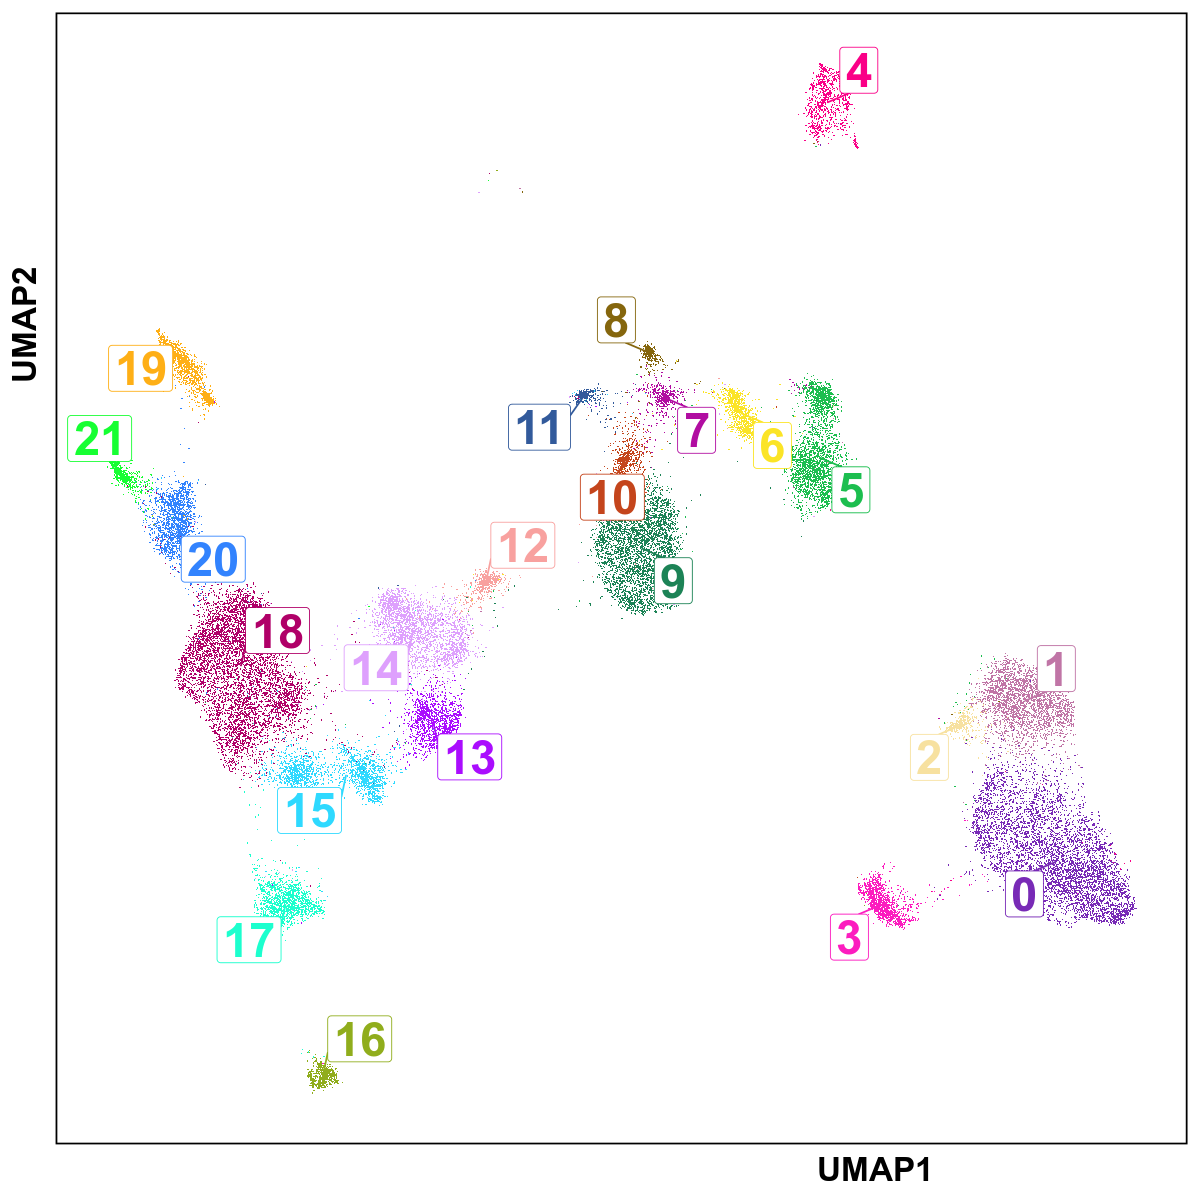

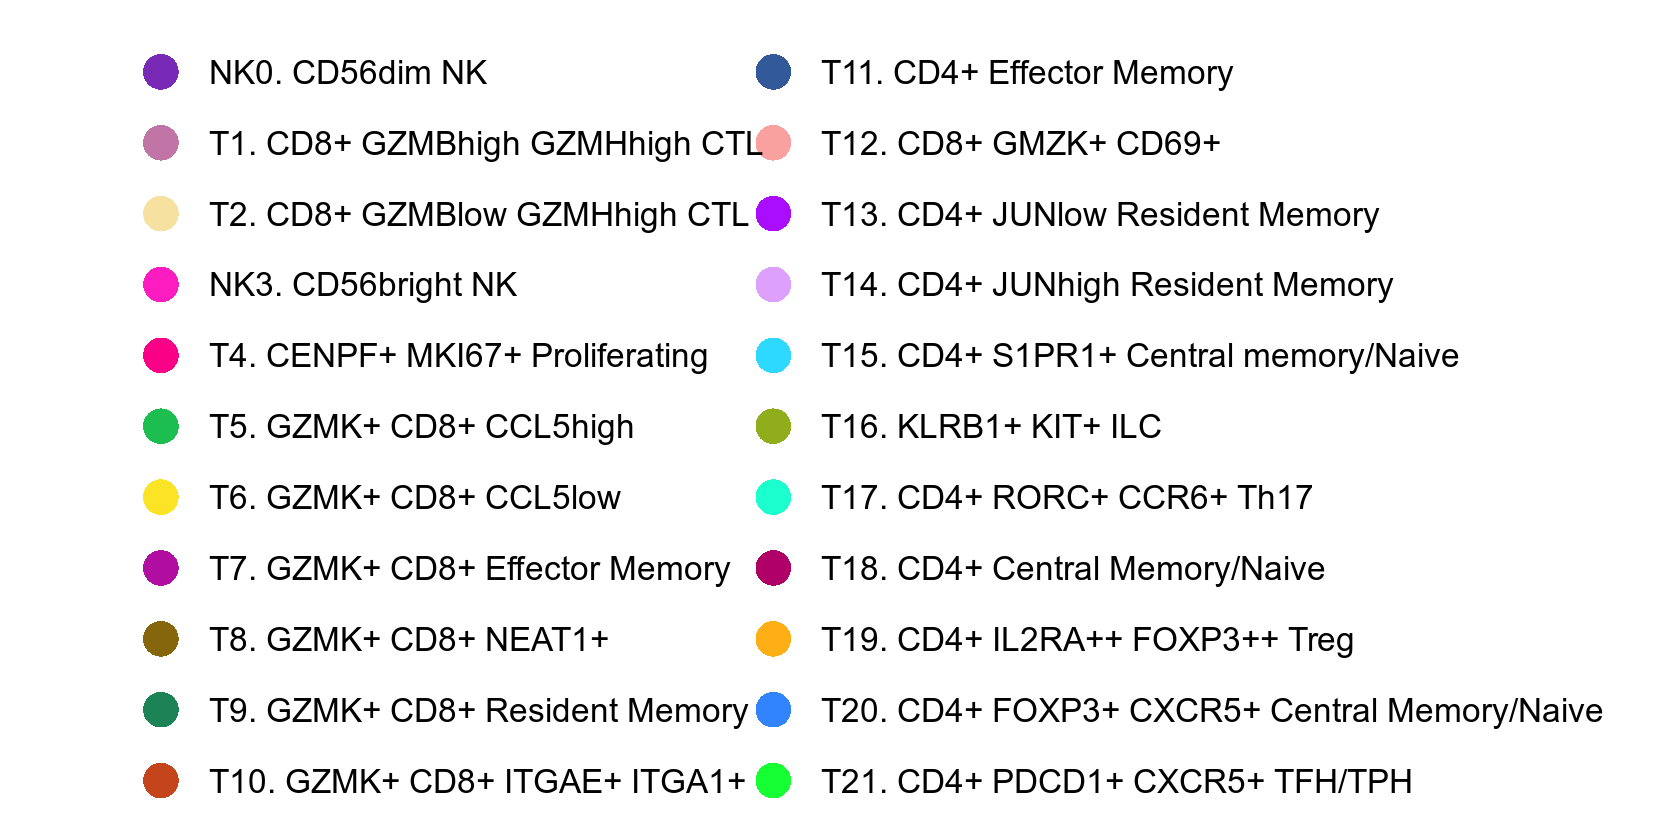

In [99]:
options(warn=-1)
cluster_center <- qcd_meta %>%
                  group_by(new_cluster_number, final_annotation) %>%
                  summarise_at(vars(hUMAP1, hUMAP2), funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)

options(repr.plot.height = 9, repr.plot.width = 18)
p <- ggplot() +
      geom_point(
        data = qcd_meta[sample(nrow(qcd_meta)), ] %>% 
          select(hUMAP1, hUMAP2, new_cluster_number, final_annotation) %>% 
                  mutate(final_annotation = factor(final_annotation, 
                                                   levels = cluster_center$final_annotation)),
        aes(x = hUMAP1, y = hUMAP2, color = final_annotation),
          size = 0.6, shape = 20, stroke = 0.0001) +
      ggrepel::geom_label_repel(
        data = cluster_center,
        aes(x = hUMAP1, y = hUMAP2, 
            label = new_cluster_number, color = as.factor(final_annotation)),
        size = 10,  fontface = "bold",
        box.padding = unit(0.5, "lines"),
        point.padding = unit(0.01, "lines"),
        show.legend = FALSE
      ) +
        scale_color_manual(values =as.vector(rev(polychrome(26)))) +
    theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1),
              legend.text = element_text(size = 20),
              legend.title = element_blank()
          
    ) +
    theme(text=element_text(family="Arial")) + 
        labs(x = "UMAP1", y = "UMAP2") +
        guides(color = guide_legend(ncol = 2, override.aes = list(size = 15)))
legend <- cowplot::get_legend(p)
p <- p + theme(legend.position = "none")
legend <- cowplot::plot_grid(legend)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure2/figure2a.png",
       p,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure2/figure2a-legend.png",
       legend,
       base_height = 7,
       base_width = 14)
fig.size(10, 10)
p
fig.size(7, 14)
legend
options(warn=0)

### Marker Gene UMAPs

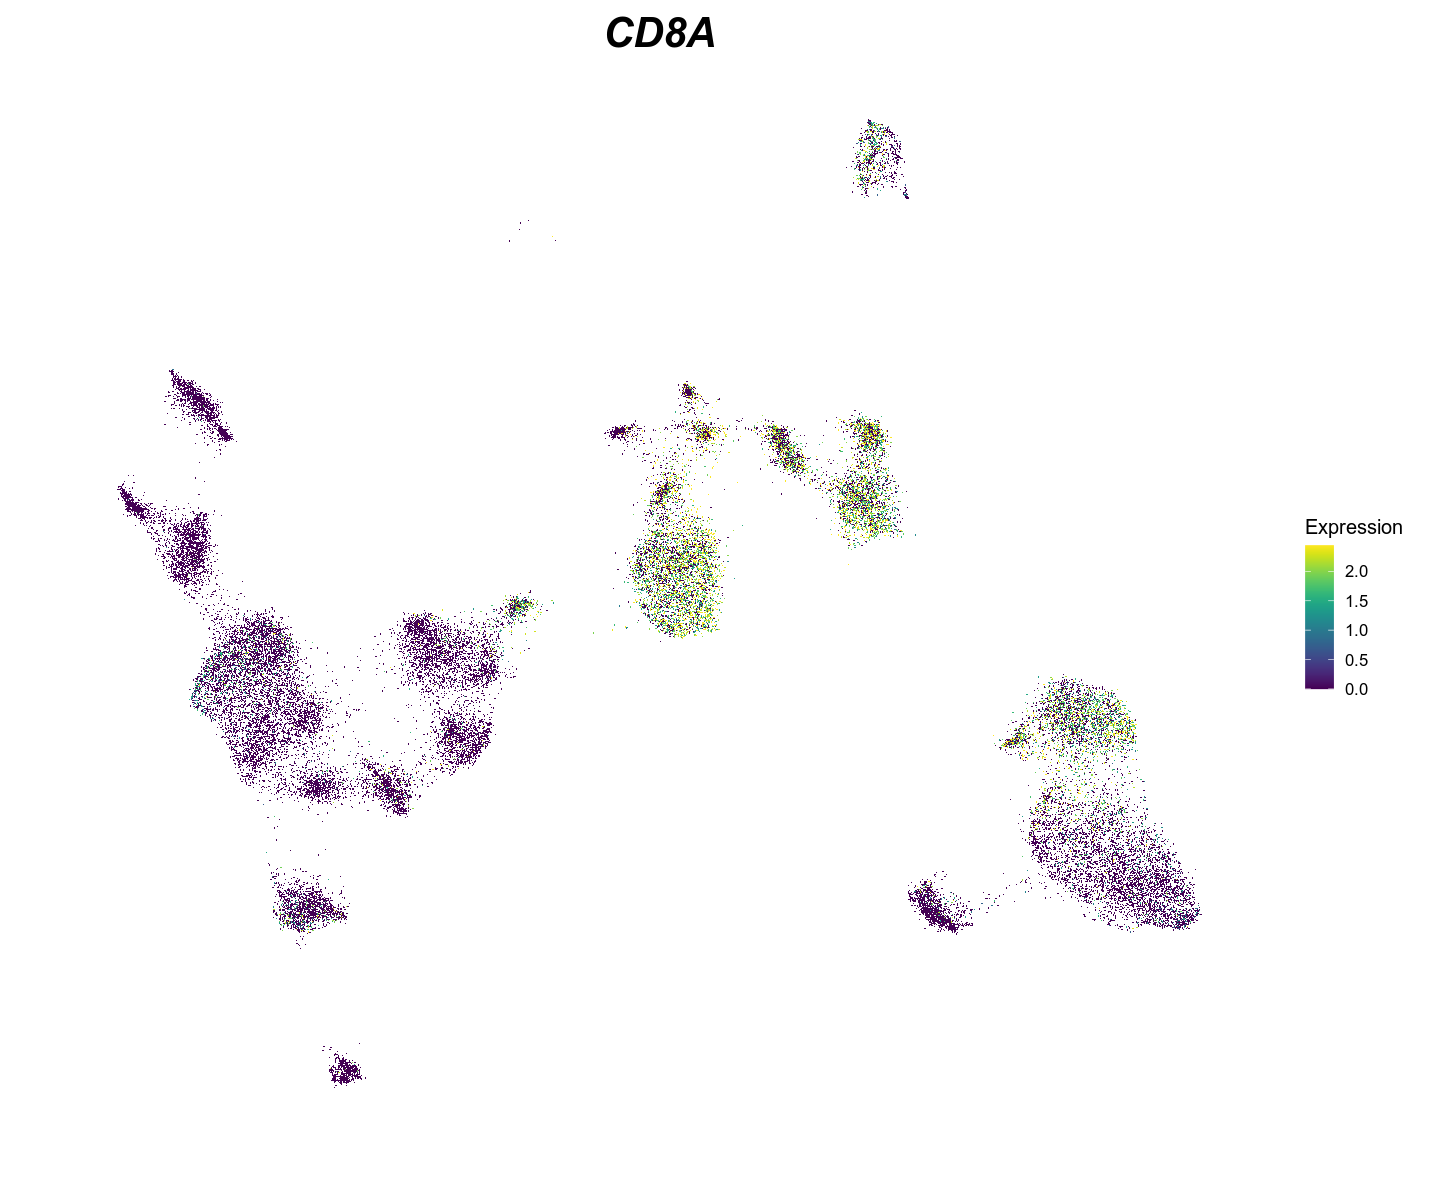

In [7]:
fig.size(10, 12)
plot_shuffled_features(qcd_meta, 
                       qcd_norm, "CD8A", pct = 0.95, pt_size = 0.6)

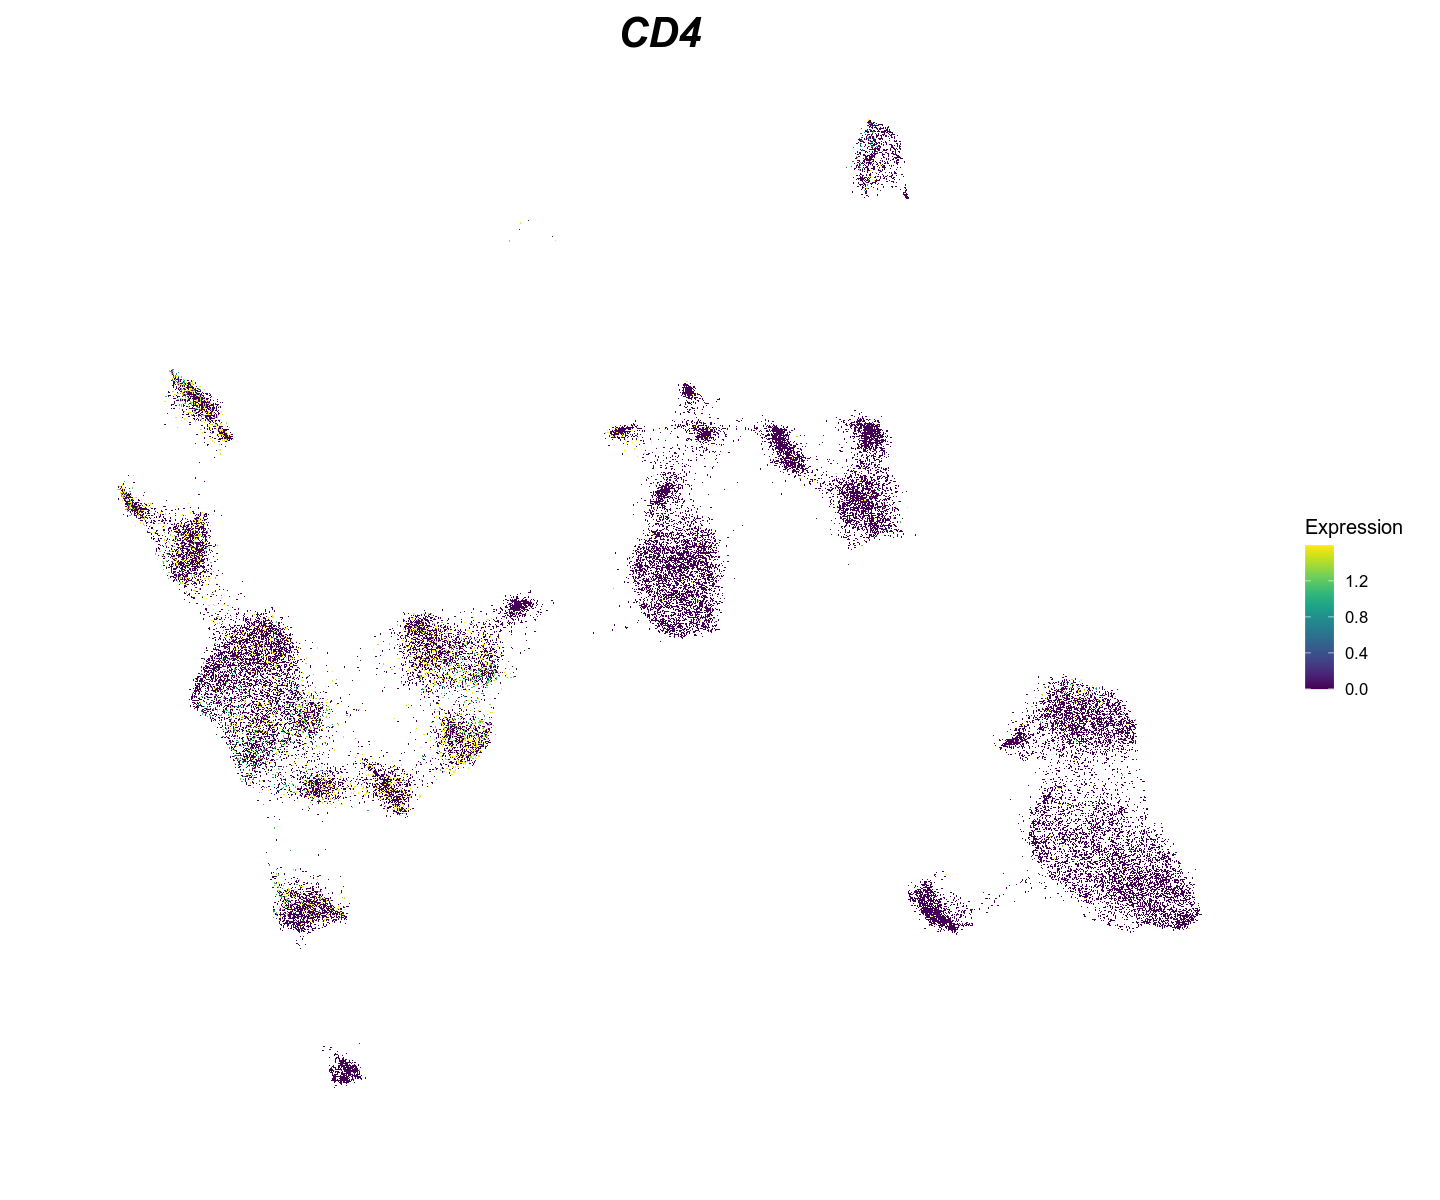

In [6]:
fig.size(10, 12)
plot_shuffled_features(qcd_meta, 
                       qcd_norm, "CD4", pct = 0.95, pt_size = 0.6)

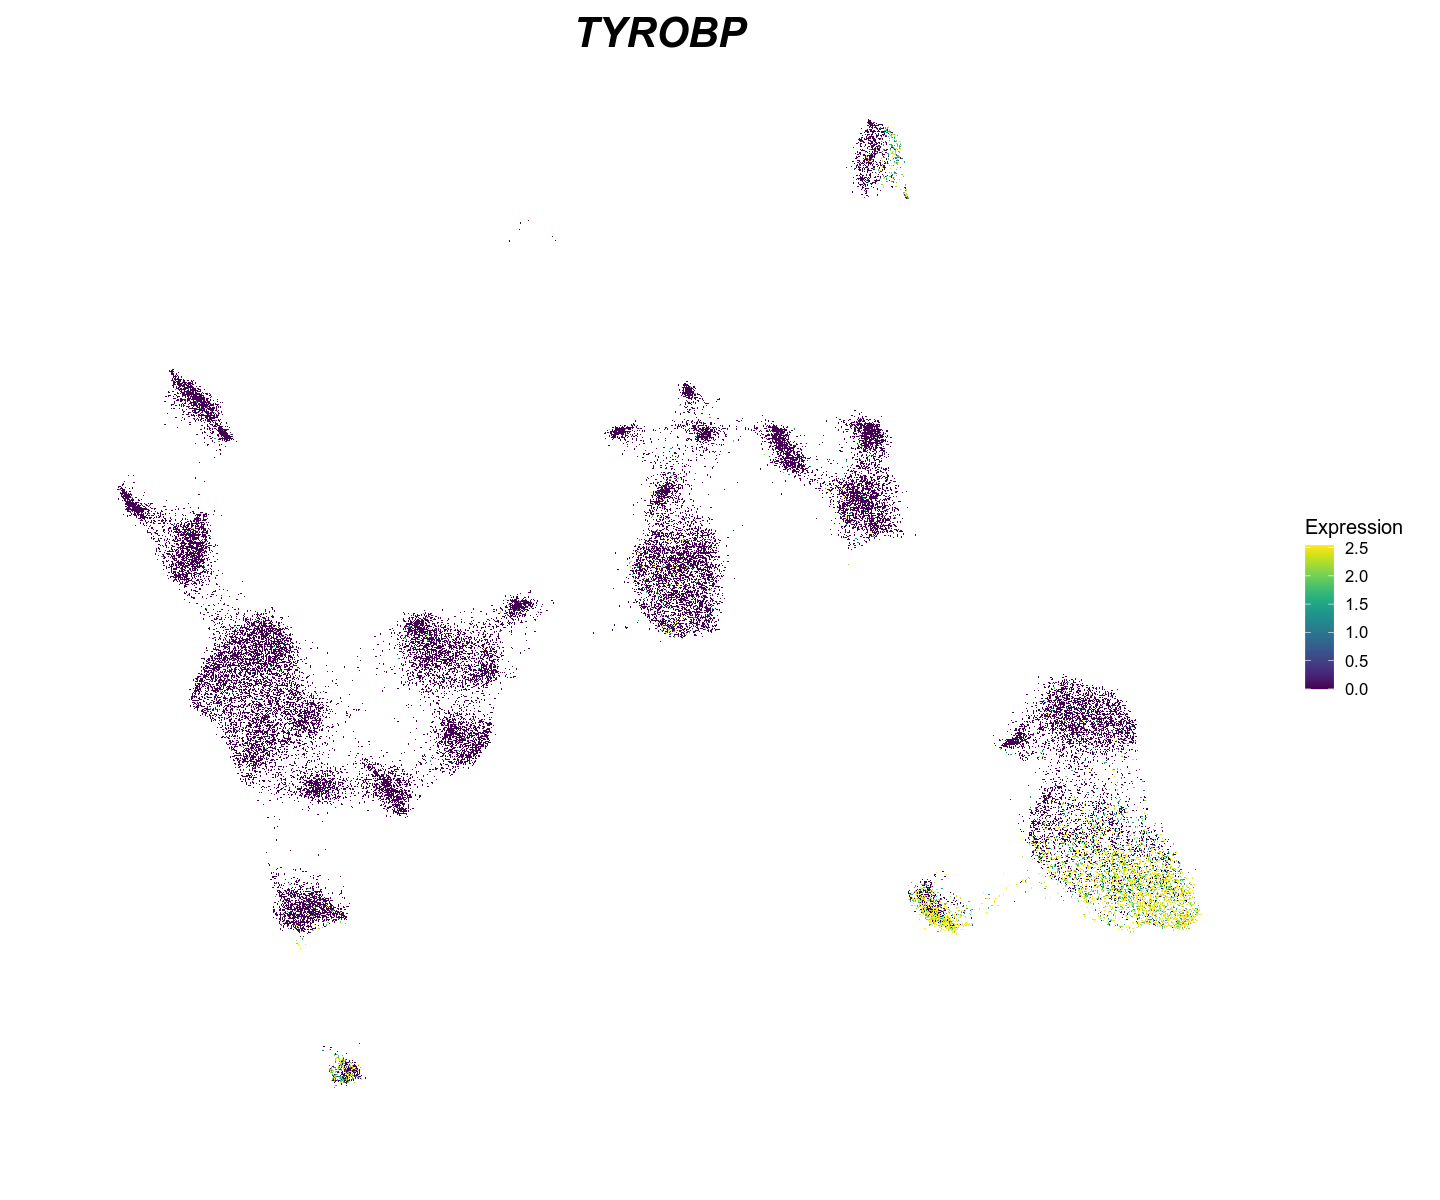

In [10]:
plot_shuffled_features(qcd_meta, 
                       qcd_norm, "TYROBP", pct = 0.95, pt_size = 0.6)

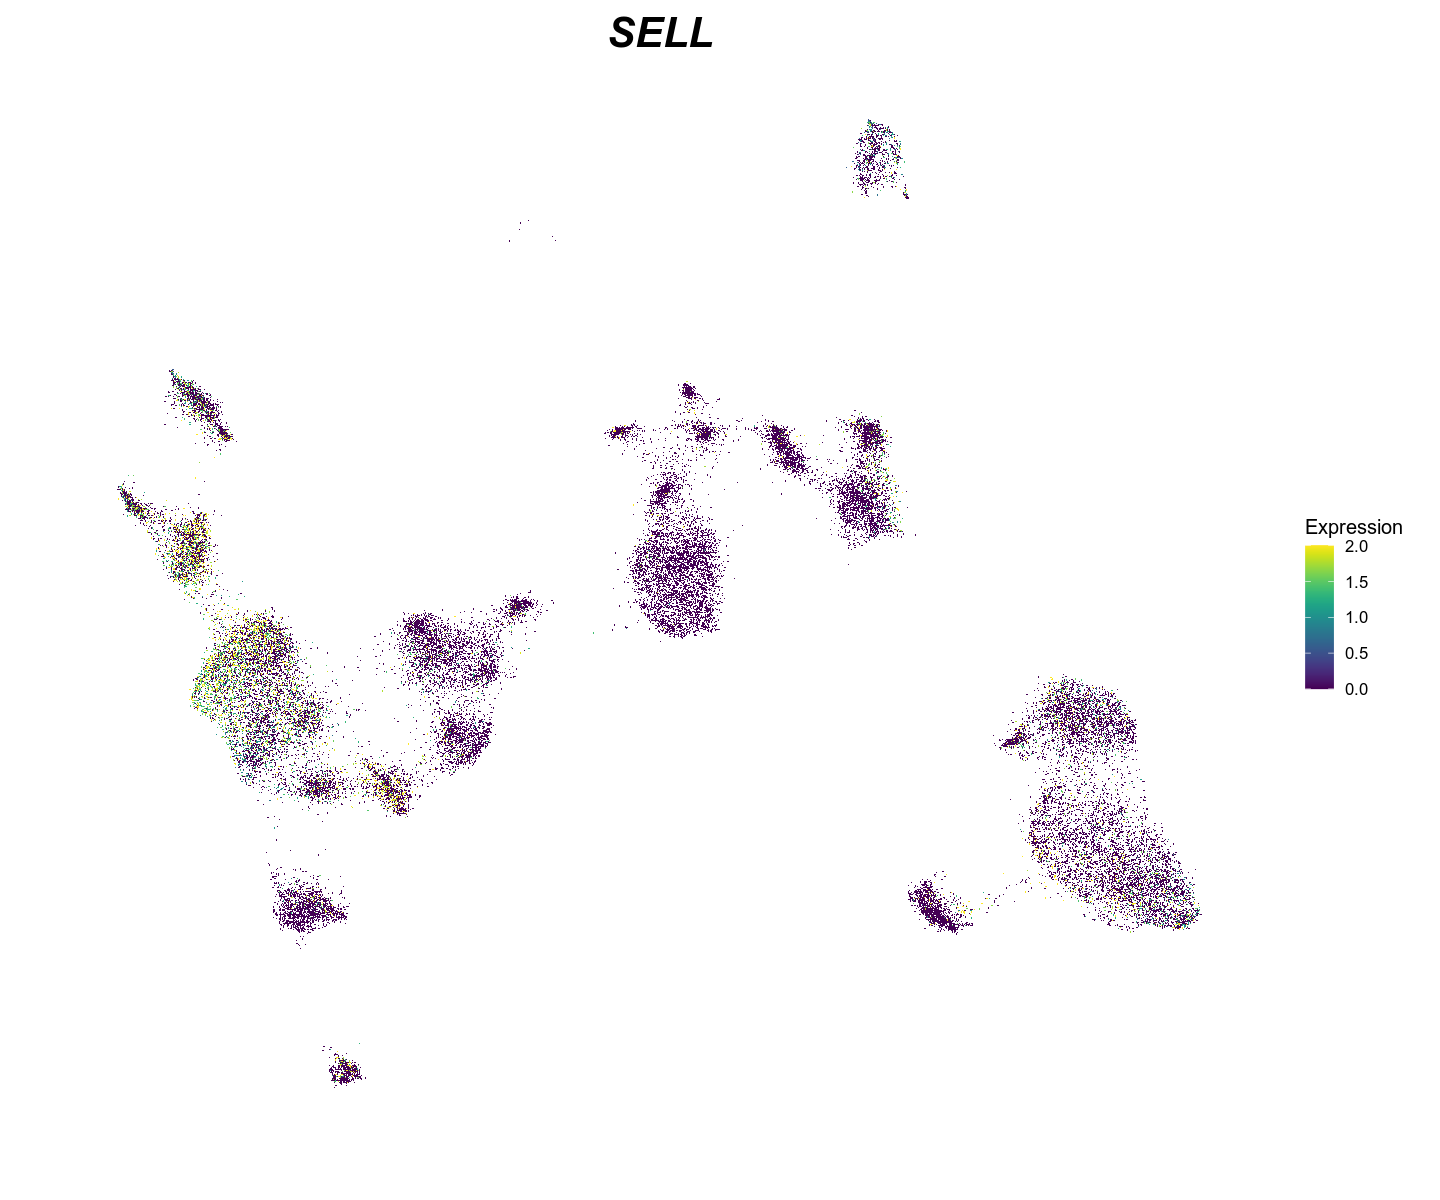

In [11]:
plot_shuffled_features(qcd_meta, 
                       qcd_norm, "SELL", pct = 0.95, pt_size = 0.6)

### Gene heatmaps

In [3]:
marker_genes <- c("NCAM1", "TYROBP", "PRF1", "GZMK", "GZMB", "SYNE2", "CD3D", "CD4", "CD8A", "CENPF", "MKI67", "NKG7", 
                 "CD28", "CCR7", "SELL", "ITGAE", "NEAT1", "S1PR1", "CD69", "JUN", "KLRB1", "KIT", "IL1R1", "IL7R",
                  "RORC", "CCR6", "IL2RA", "FOXP3", "PDCD1", "CXCR5")

In [ ]:
wilcox_sn <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(final_annotation))
wilcox_sc <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(final_annotation))

In [6]:
sc_plot_df <- wilcox_sc %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
sn_plot_df <- wilcox_sn %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

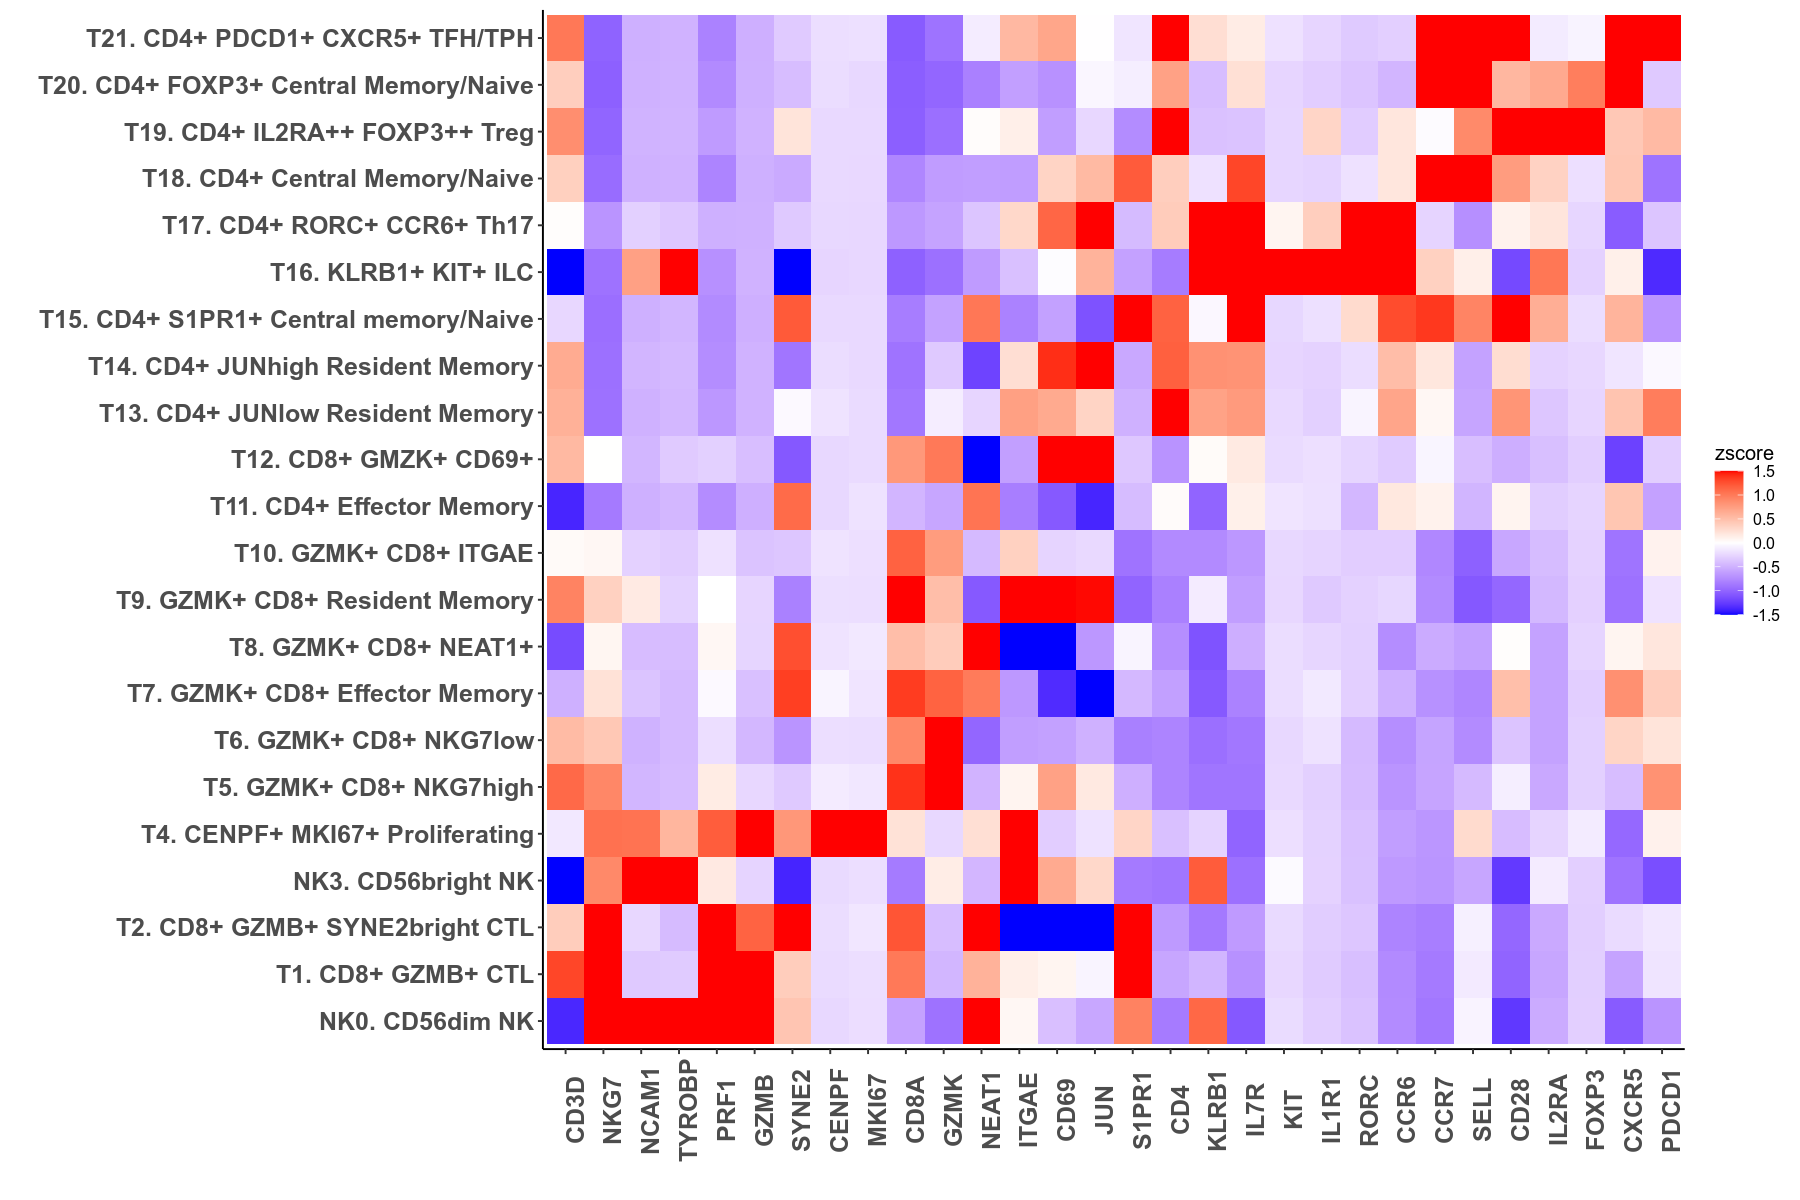

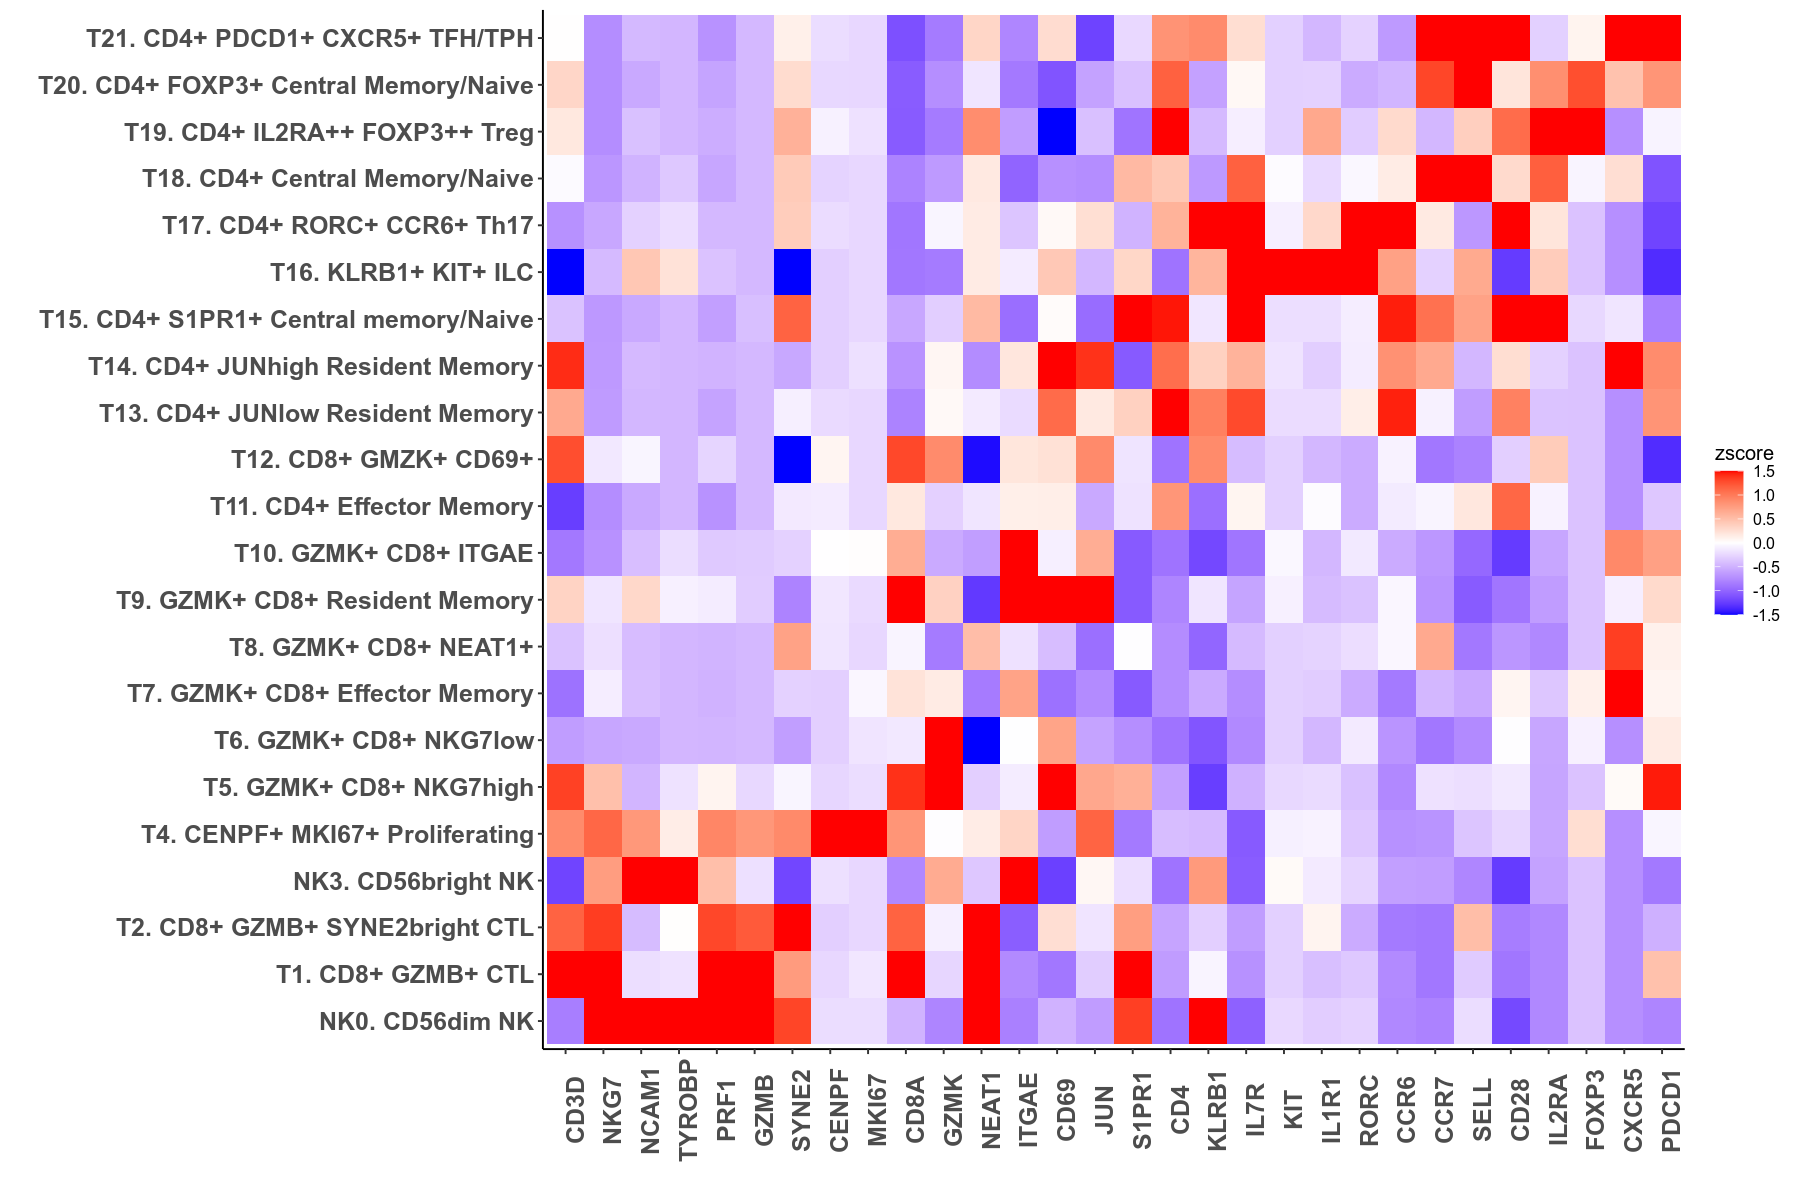

In [35]:
fig.size(10, 15)
ggplot(sc_plot_df %>% rename(percent = pct_in,
                             zscore = avgExpr_scaled), 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish) + 
    scale_x_discrete(limits = marker_genes) + 
    scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(face = "bold", size = 15),
          axis.title = element_text(size = 15)) + 
    labs(x = "", y = "")
fig.size(10, 15)
ggplot(sn_plot_df %>% rename(percent = pct_in,
                             zscore = avgExpr_scaled), 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish) + 
    scale_x_discrete(limits = marker_genes) + 
    scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(face = "bold", size = 15),
          axis.title = element_text(size = 15)) + 
    labs(x = "", y = "")

In [3]:
wilcox <- wilcoxauc(qcd_norm[, qcd_meta %>% pull(cell)], 
                       qcd_meta %>% pull(final_annotation))

In [4]:
annotation.order = c("NK0. CD56dim NK",
                     "NK3. CD56bright NK",
                     "T1. CD8+ GZMBhigh GZMHhigh CTL",
                     "T2. CD8+ GZMBlow GZMHhigh CTL",
                     "T4. CENPF+ MKI67+ Proliferating",
                     "T5. GZMK+ CD8+ CCL5high",
                     "T6. GZMK+ CD8+ CCL5low",
                     "T7. GZMK+ CD8+ Effector Memory",
                     "T8. GZMK+ CD8+ NEAT1+",
                     "T9. GZMK+ CD8+ Resident Memory",
                     "T10. GZMK+ CD8+ ITGAE+ ITGA1+",
                     "T11. CD4+ Effector Memory",
                     "T12. CD8+ GMZK+ CD69+",
                     "T13. CD4+ JUNlow Resident Memory",
                     "T14. CD4+ JUNhigh Resident Memory",
                     "T15. CD4+ S1PR1+ Central memory/Naive",
                     "T16. KLRB1+ KIT+ ILC",
                     "T17. CD4+ RORC+ CCR6+ Th17",
                     "T18. CD4+ Central Memory/Naive",
                     "T19. CD4+ IL2RA++ FOXP3++ Treg",
                     "T20. CD4+ FOXP3+ CXCR5+ Central Memory/Naive",
                     "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH")

In [5]:
marker.genes <- c("CD3D", "CD4", "CD8A", "CD28", "CCR7", "SELL", "S1PR1", "NCAM1", "GNLY", "FCGR3A",
                  "PRF1", "GZMH", "GZMB", "CENPF", "MKI67", "CCL5", "GZMK", 
                  "NEAT1", "ITGAE", "ITGA1", "CD69", "JUN", "KLRB1", "KIT", "IL1R1", "IL7R",
                  "RORC", "CCR6", "IL2RA", "FOXP3", "CXCR5", "PDCD1")

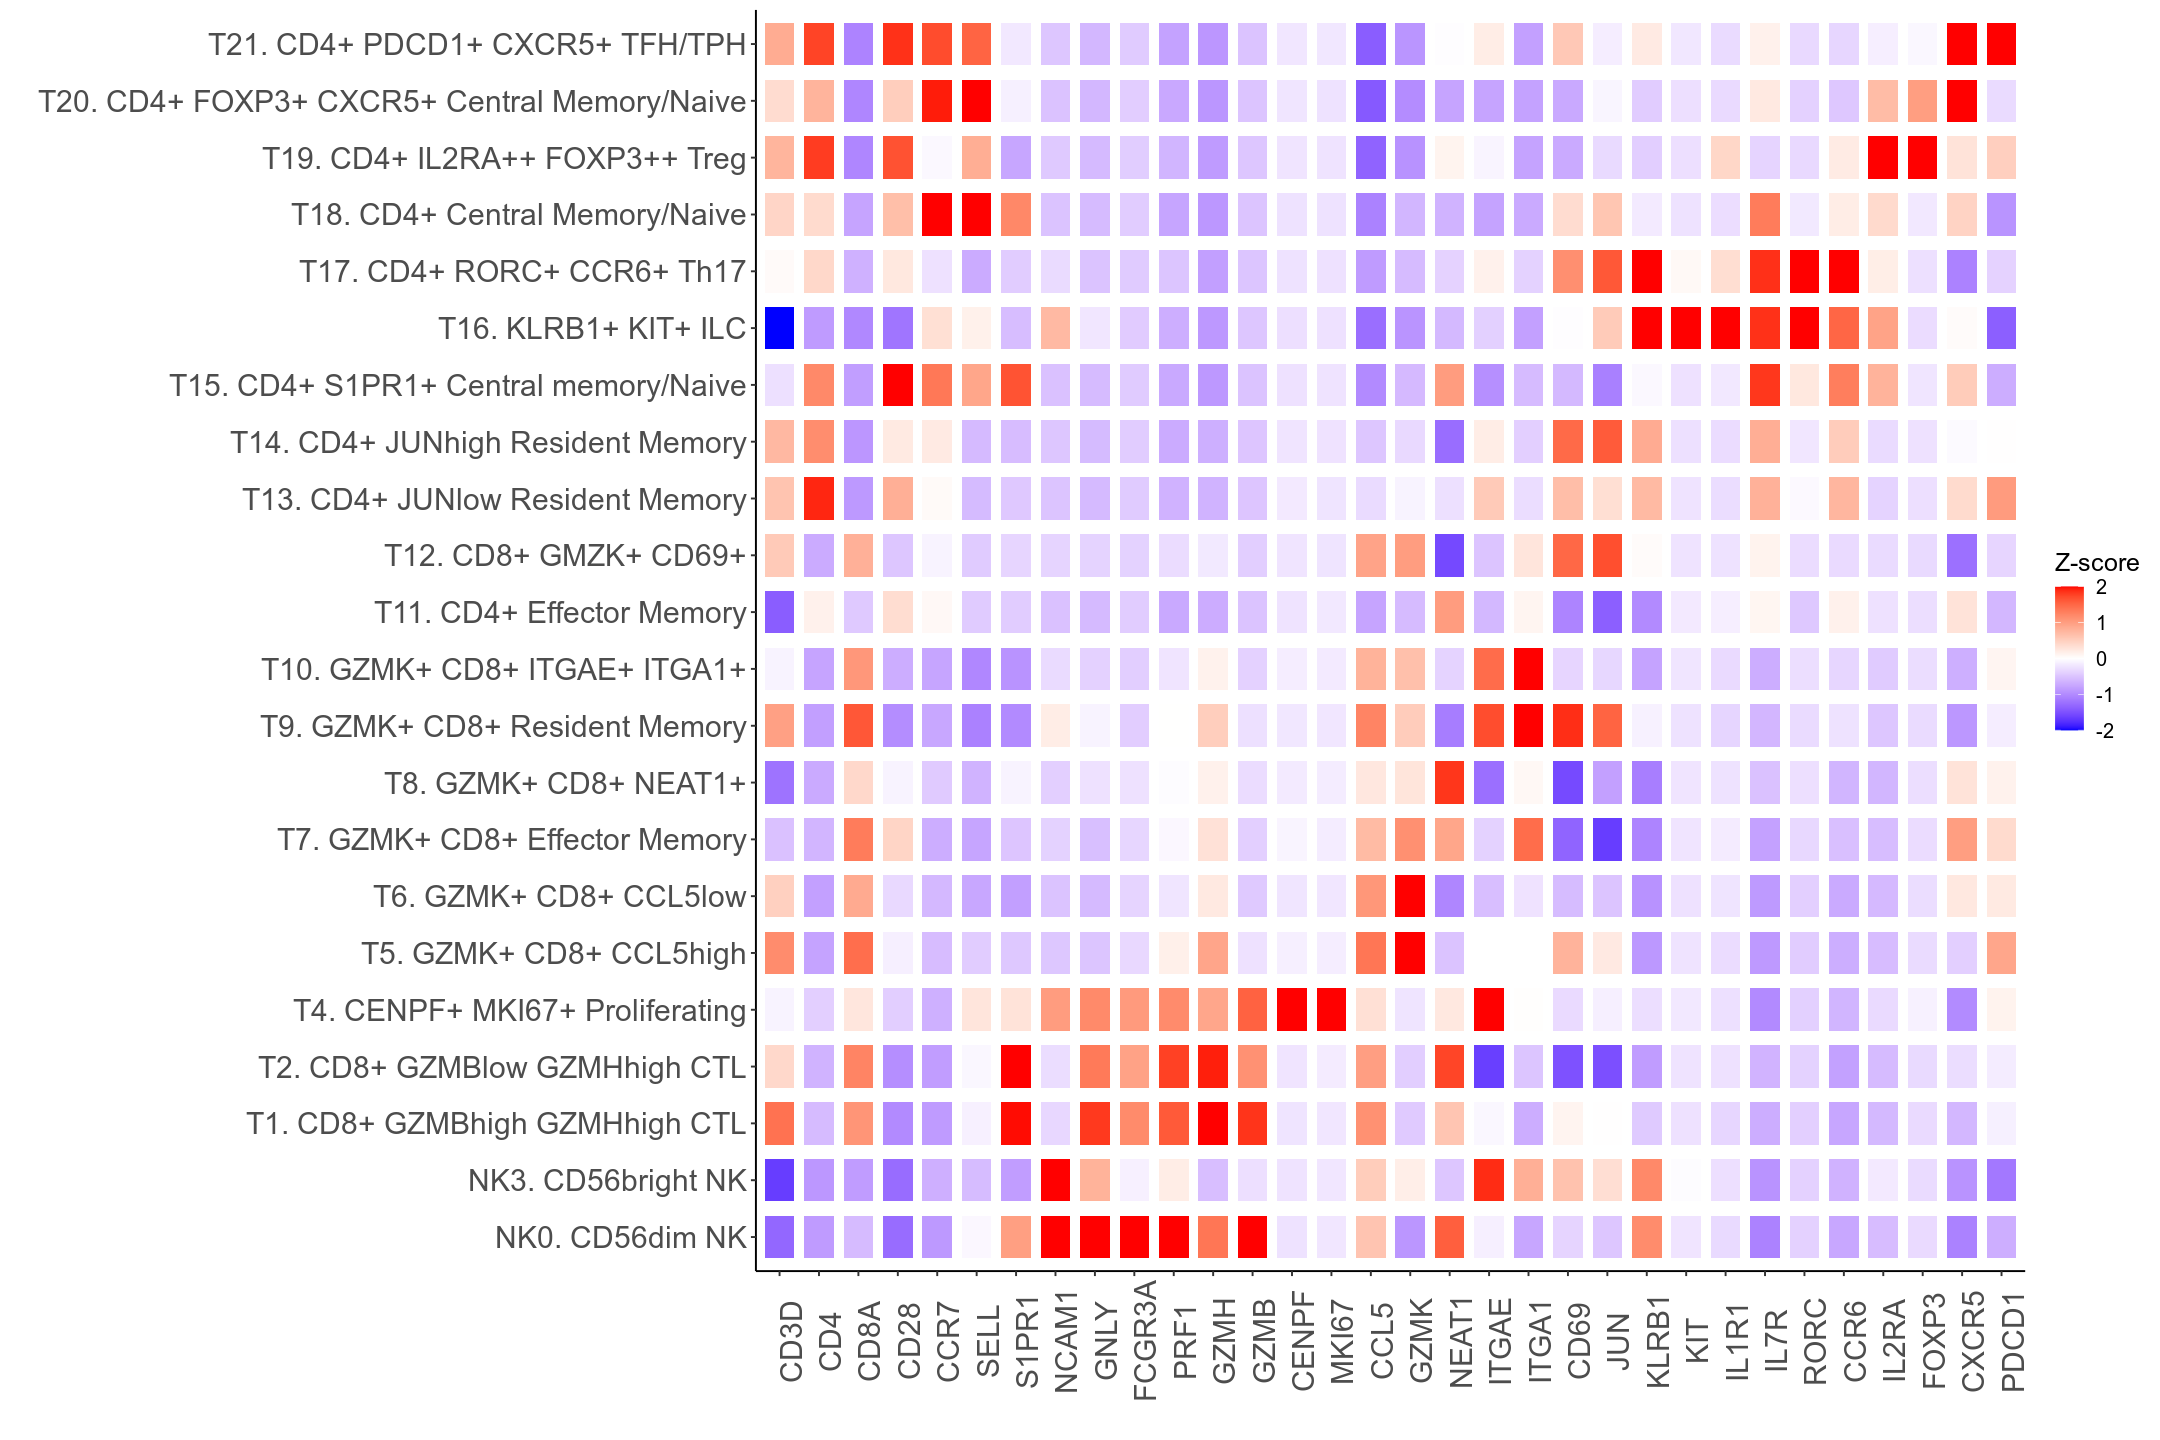

In [8]:
plot_df <- wilcox %>%  filter(feature %in% marker.genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

fig.size(12, 18)
heatmap <- ggplot(plot_df %>% rename(percent = pct_in,
                             zscore = avgExpr_scaled), 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile(width = 0.75, height = 0.75) + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-2, 2), 
                         oob = scales::squish,
                         name = "Z-score") +
    scale_x_discrete(limits = marker.genes) + 
    scale_y_discrete(limits = annotation.order) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(size = 18),
          axis.title = element_text(size = 15),
          legend.title = element_text(size = 15),
          legend.text = element_text(size = 12)) + 
    theme(text=element_text(family="Arial")) + 
    labs(x = "", y = "")
heatmap
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure1/t-nk.png",
       heatmap,
       base_height = 12,
       base_width = 18)

### Cluster Proportions in Matched Patients

In [123]:
qcd_meta <- qcd_meta  %>% 
                mutate(individual = str_split(sample, '_')) %>% 
                rowwise() %>% 
                mutate(individual = unlist(individual)[3]) 

In [124]:
sample_freq <- qcd_meta %>% select(dataset, individual, new_cluster_number) %>% 
                    table() %>% data.frame() %>% 
                    pivot_wider(names_from = "new_cluster_number", values_from = Freq) 

In [125]:
ind_list <- qcd_meta %>% select(dataset, individual) %>% 
                table() %>% data.frame() %>% 
                pivot_wider(names_from = 'dataset', values_from = "Freq") %>% filter(scRNAseq > 40 & snRNAseq > 40) %>% 
                pull(individual)

In [126]:
sample_freq_sc <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "scRNAseq") %>% 
                    select(-dataset) %>% colSums()

sample_freq_sn <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "snRNAseq") %>% 
                    select(-dataset) %>% colSums()

In [127]:
sample_freq <- data.frame(rep("a", 22))
sample_freq$sc_freq <- sample_freq_sc / sum(sample_freq_sc)
sample_freq$sc_se <- sqrt((sample_freq$sc_freq * (1 - sample_freq$sc_freq)) / sample_freq_sc)
sample_freq$sn_freq <- sample_freq_sn / sum(sample_freq_sn)
sample_freq$sn_se <- sqrt((sample_freq$sn_freq * (1 - sample_freq$sn_freq)) / sample_freq_sn)
sample_freq <- sample_freq[,- 1]
sample_freq$new_cluster_number <- as.character(seq(0, 21))

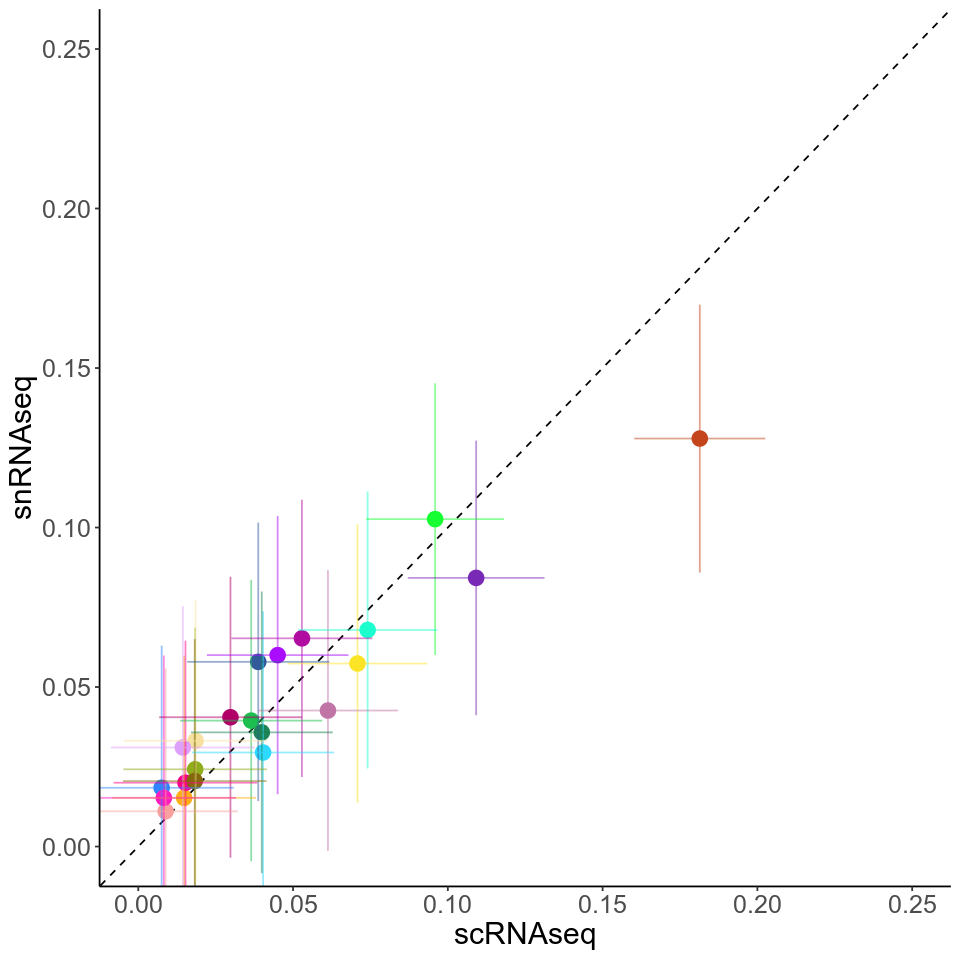

In [128]:

fig.size(8, 8)

max_val <- max(sample_freq[, c("sc_freq", "sn_freq")])

ggplot(sample_freq, aes(x = sc_freq, y = sn_freq, color = new_cluster_number)) + 
    geom_abline(linetype = "dashed") +
    scale_color_manual(values =as.vector(rev(polychrome(26)))) +
    theme_classic() + 
    geom_point(size = 4) + 
    geom_linerange(aes(ymax = sn_freq+1.96*sn_se, 
                        ymin = sn_freq-1.96*sn_se), alpha = 0.5) +
    geom_linerange(aes(xmax = sc_freq+1.96*sc_se, 
                        xmin = sc_freq-1.96*sc_se), alpha = 0.5) +
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18)) +
    coord_cartesian(xlim = c(0, 0.25), ylim = c(0, 0.25)) + 
    labs(x = "scRNAseq",
         y = "snRNAseq")

In [129]:
cor.test(sample_freq$sc_freq, sample_freq$sn_freq)


	Pearson's product-moment correlation

data:  sample_freq$sc_freq and sample_freq$sn_freq
t = 12.517, df = 20, p-value = 6.428e-11
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8625489 0.9758631
sample estimates:
      cor 
0.9417005 


## Case/Control Figure

### CASE/CONTROL CNA

In [5]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')
tnk_rawcounts <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_rawcounts_03062023.rds')
mito_genes_subset <- c("MT-ND5", "MT-ND6")
percent_mito <- colSums(tnk_rawcounts[mito_genes_subset, ]) / colSums(tnk_rawcounts) * 100
percent_mito <- data.frame(cell = names(percent_mito), percent.mt = percent_mito)
qcd_meta <- left_join(qcd_meta, percent_mito) %>% select(-final_annotation)
final_annotation <- data.frame(new_cluster_number = seq(0, 21),
                                final_annotation = c("NK0. CD56dim NK",
                                 "T1. CD8+ GZMBhigh GZMHhigh CTL",
                                 "T2. CD8+ GZMBlow GZMHhigh CTL",
                                 "NK3. CD56bright NK",
                                 "T4. CENPF+ MKI67+ Proliferating",
                                 "T5. GZMK+ CD8+ CCL5high",
                                 "T6. GZMK+ CD8+ CCL5low",
                                 "T7. GZMK+ CD8+ Effector Memory",
                                 "T8. GZMK+ CD8+ NEAT1+",
                                 "T9. GZMK+ CD8+ Resident Memory",
                                 "T10. GZMK+ CD8+ ITGAE+ ITGA1+",
                                 "T11. CD4+ Effector Memory",
                                 "T12. CD8+ GMZK+ CD69+",
                                 "T13. CD4+ JUNlow Resident Memory",
                                 "T14. CD4+ JUNhigh Resident Memory",
                                 "T15. CD4+ S1PR1+ Central memory/Naive",
                                 "T16. KLRB1+ KIT+ ILC",
                                 "T17. CD4+ RORC+ CCR6+ Th17",
                                 "T18. CD4+ Central Memory/Naive",
                                 "T19. CD4+ IL2RA++ FOXP3++ Treg",
                                 "T20. CD4+ FOXP3+ CXCR5+ Central Memory/Naive",
                                 "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH"))

qcd_meta <- qcd_meta %>% left_join(final_annotation)
sc_meta <- qcd_meta %>% filter(dataset == "scRNAseq")

Joining with `by = join_by(cell, percent.mt)`
Joining with `by = join_by(new_cluster_number)`


In [50]:
sc_meta <- qcd_meta[, !colnames(qcd_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = qcd_meta$sample) %>% 
                        filter(dataset == 'scRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical %>% select(Final_Site, Age, Sex, Type, individual))

meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Type)]

meta <- meta[ind, ]
umap <- umap[ind, ]
harmony <- harmony[ind, ]

meta <- meta %>% mutate(Type_numeric = ifelse(Type == "LN", 1, 0))


# write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_meta.csv', 
#           row.names = FALSE, quote = FALSE)
# write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_harmony.csv', 
#           row.names = FALSE, quote = FALSE)
# write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_umap.csv', 
#           row.names = FALSE, quote = FALSE)

Joining, by = "individual"


#### RESULTS

In [8]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_meta.csv')
harmony <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_harmony.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_umap.csv')

fdrs <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_fdrs.csv', header = FALSE)
ncorr <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/case_control/sc_ncorr.csv', header = FALSE)

colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

In [43]:
getwd()

[1] "/data/srlab/ssg34/SLE_kidney_v2/scripts/figure_notebooks"

In [173]:
title = 'T/NK'
subset <- c(3, 5, 9, 12, 13, 14, 15, 17, 19, 20, 21)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Arial' not found in PostScript font database”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE

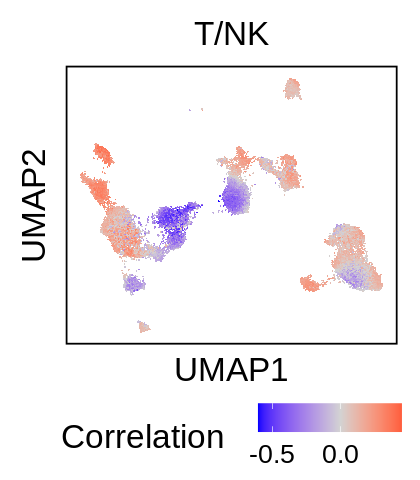

In [183]:
fig.size(3, 3)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 1e-10, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 1e-10, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey",
                            guide = guide_colorbar(direction = "horizontal"),
                           breaks = seq(-1, 1, by = 0.5)
                           ) + 
    theme_classic(base_size = tickfontsize) +
      theme(
        legend.position = "right",
        legend.text = element_text(size = labelfontsize-4),
        legend.title = element_text(size = labelfontsize),
          plot.title = element_text(hjust = 0.5, size = labelfontsize),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
    labs(title = title, x = "UMAP1", y = "UMAP2", color = 'Correlation') + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)


height = 4
width = 3.5
fig.size(height, width)
outplot = cna_umap + umap_legend + plot_layout(heights = c(6, 1.5))
outplot

ggsave(paste0(figdir, 'tnk_cna_umap.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_cna_umap.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`
Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`
Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`


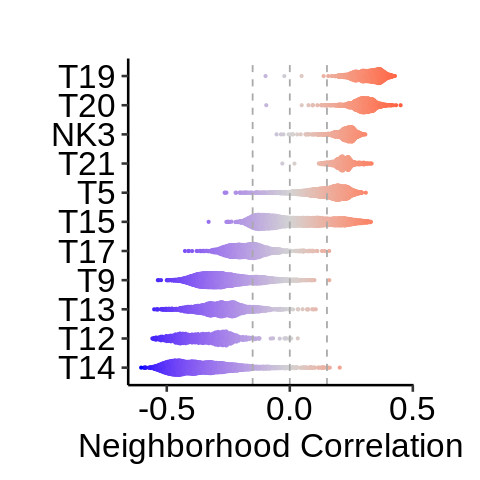

In [184]:
meta = meta %>% mutate(final_annotation_num = final_annotation %>% str_split('. ') %>% map(1) %>% unlist)
pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


violin_plot <- ggplot(meta %>% filter(new_cluster_number %in% subset), aes(y = reorder(final_annotation_num, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey",
                                            guide = guide_colorbar(direction = "horizontal"),
                                           breaks = seq(-1, 1, by = 0.5)
                                           ) + 
                    scale_x_continuous(breaks = pretty(meta$ncorr, n = 3)) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = tickfontsize) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = labelfontsize, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = labelfontsize, hjust=1),
                        axis.title = element_text(size=labelfontsize, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black'),
                        axis.line.y.left   = element_line(color = 'black'),
                        plot.margin = margin(10, 40, 10, 10)
                         
                         )

height = 4
width = 4
fig.size(height, width)
outplot = violin_plot #+ plot_layout(heights = c(6, 1.5))
outplot

ggsave(paste0(figdir, 'tnk_violin_plot.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_violin_plot.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [53]:
ci_summary <- meta %>% =
                select(new_cluster_number, cell, ncorr) %>% 
                group_by(new_cluster_number) %>% 
                summarize(ncorr.ci = paste0("(", round(mean(ncorr) - 1.96 * sd(ncorr) / sqrt(length(cell)), 3),
                                      ", ", round(mean(ncorr) + 1.96 * sd(ncorr) / sqrt(length(cell)), 3), ")"))
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/case_control.rds') %>% 
            mutate(new_cluster_number = as.numeric(str_remove(cluster, "cluster")),
               OR.ci = paste0("(", round(Type.OR.95pct.ci.lower, 3), ", ", 
                              round(Type.OR.95pct.ci.upper, 3), ")")) %>% 
        select(new_cluster_number, OR.ci)

summary <- ci_summary %>% left_join(res)
write.csv(summary, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/tnk_casecontrol_corr_04152024.csv', quote = FALSE, row.names = FALSE)

Joining, by = "new_cluster_number"


### PSEUDOBULK DE

In [8]:
out <- mclapply(unique(qcd_meta$sample), pseudobulk, qcd_meta, qcd_norm,
               mc.cores = 6)
tnk_pb <- data.frame(do.call(rbind, out))

In [13]:
sample_stats <- qcd_meta %>% group_by(sample) %>% summarize(avg_count = mean(nCount_RNA), avg_mt = mean(percent.mt))
tnk_pb <- tnk_pb %>% left_join(sample_stats) %>% left_join(unique(qcd_meta %>% select(sample, Type)))
tnk_pb <- tnk_pb[grep("cells", tnk_pb$sample), ]
colnames(tnk_pb)[1:36601] <- rownames(qcd_norm)

Joining, by = "sample"
Joining, by = "sample"


In [15]:
saveRDS(tnk_pb, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_norm_pseudobulk_12072023.rds')

In [3]:
tnk_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_norm_pseudobulk_12072023.rds')

In [ ]:
de_out <- mclapply(rownames(qcd_norm), de, tnk_pb, mc.cores = 20)

In [18]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [23]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_case_control_differential_expression_120722023.rds')

In [12]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_case_control_differential_expression_120722023.rds')

In [13]:
de_df <- de_df %>% na.omit()

In [14]:
genes <- c("CXCR4", "NFKBIA", "IL7R", "FKBP5", "PRDM1", 
           "BST2", "PFN1", "CD74", "ISG15", "IFI44L")

Warning message:
“Removed 19065 rows containing missing values (`geom_text_repel()`).”


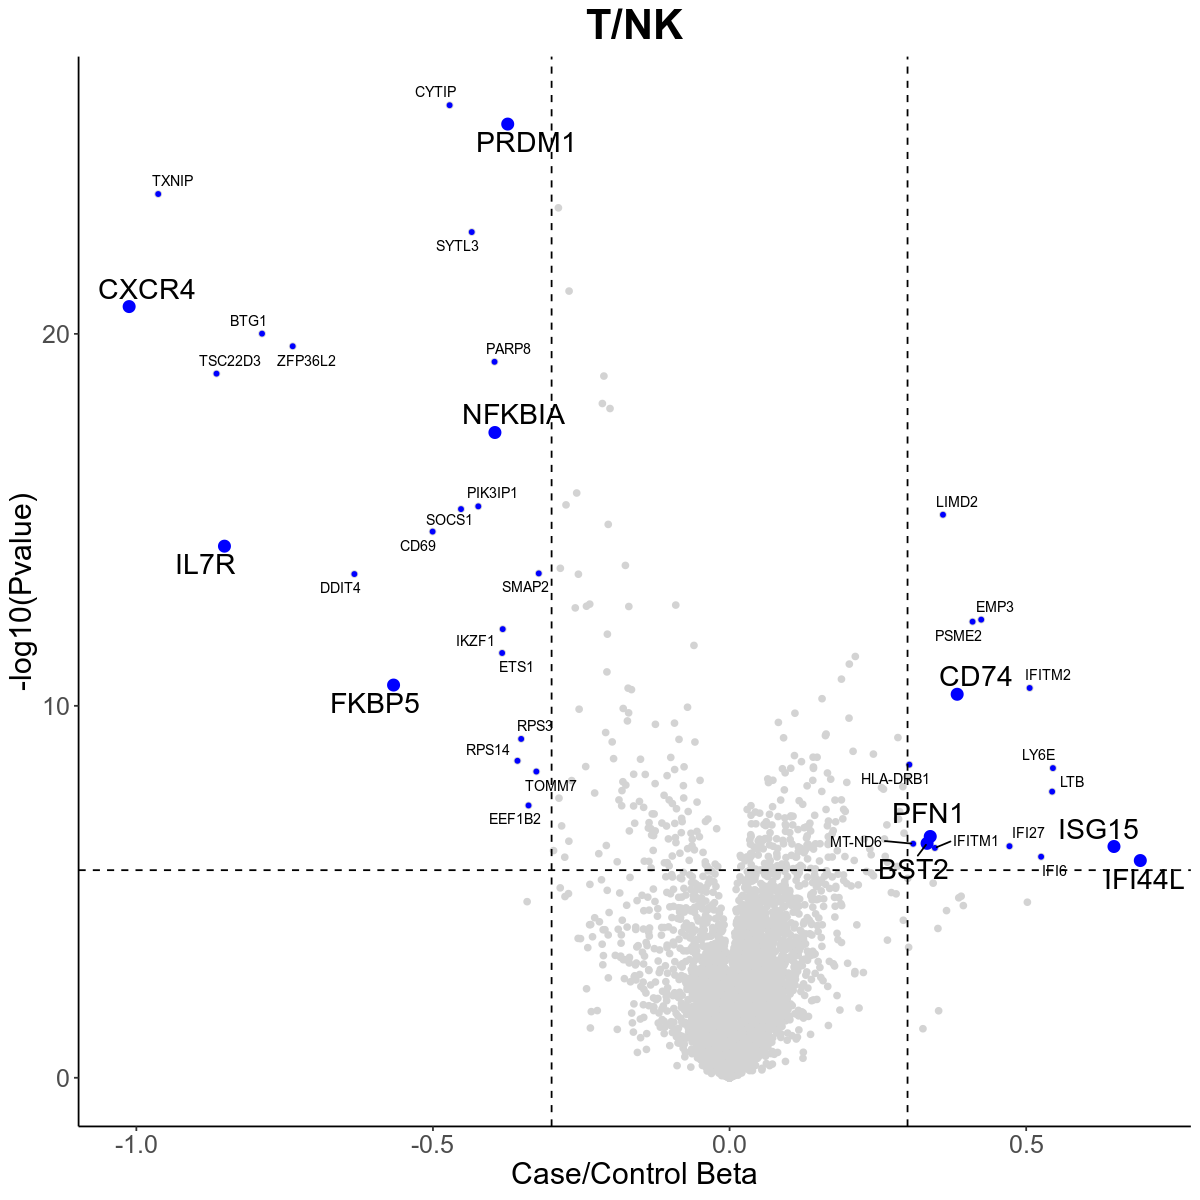

In [16]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(LRP))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(LRP < 0.05/nrow(de_df) & abs(Beta) >= 0.3,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(LRP)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(LRP)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.3, 0.3), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05/nrow(de_df)), linetype = "dashed") + 
    theme_classic() + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(LRP < 0.05/nrow(de_df) & abs(Beta) >= 0.3 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(LRP), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Case/Control Beta", y = "-log10(Pvalue)", title = "T/NK")

### MASC

In [57]:
model_df <- sc_meta %>% select(sample, processing.batch, Type, nCount_RNA, percent.mt, new_cluster_number)
model_df <- model_df %>% 
                mutate(Type = ifelse(Type == "LN", 1, 0),
                       nCount_RNA = log(nCount_RNA))

In [58]:
res <- MASC.me(model_df, factor(model_df$new_cluster_number),
                contrast = "Type",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", "percent.mt"),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Using null model: cluster ~ nCount_RNA + percent.mt + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Creating logistic mixed models for cluster19

Creating logistic mixed models for cluster2

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.106351 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”
Warning

In [59]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/case_control.rds')

In [24]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/case_control.rds')

In [25]:
res <- res %>% 
        rowwise() %>% 
        mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(0, 3), 
                                paste0('NK', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('T', unlist(str_split(cluster, 'cluster'))[2])))

Warning message:
“Removed 11 rows containing missing values (`geom_label_repel()`).”
Warning message:
“Removed 11 rows containing missing values (`geom_label_repel()`).”


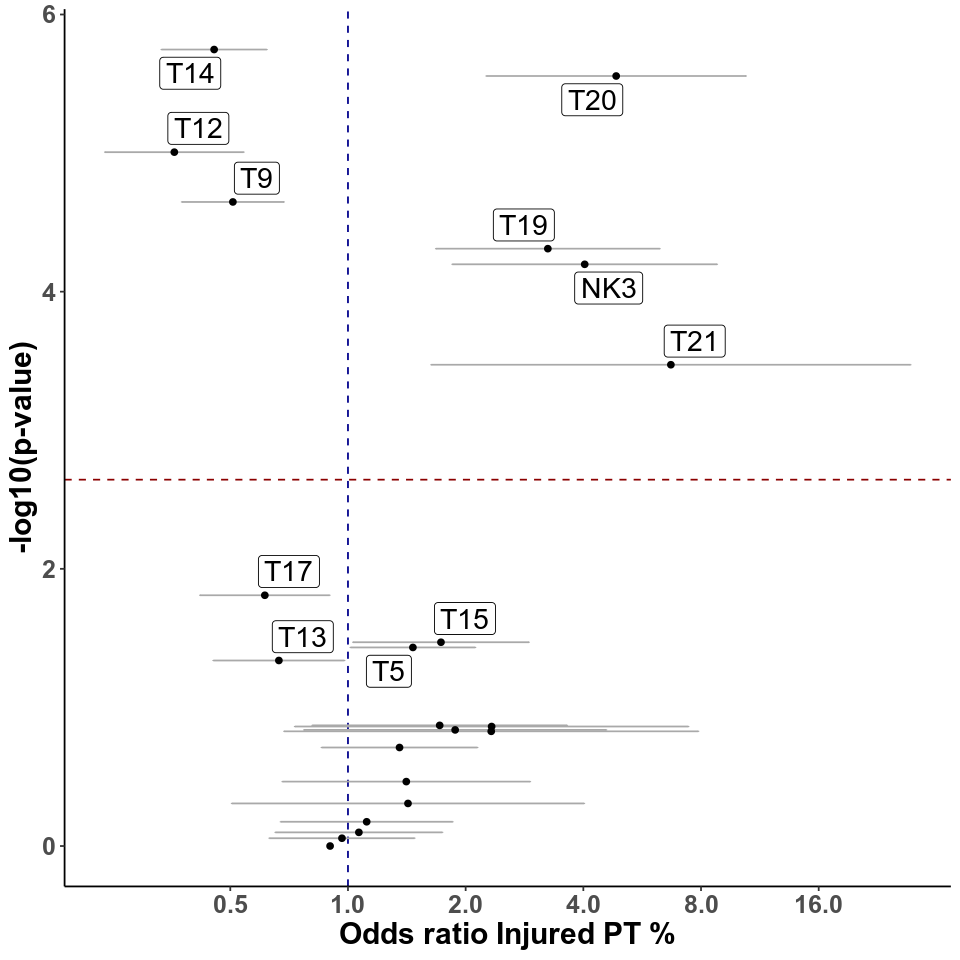

In [30]:
fig.size(8, 8)
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = Type.OR, y = -log10(model.pvalue))) +
                theme_classic() + ylab("-log10(p-value)") + xlab("Odds ratio CaseControl") +
                geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=Type.OR.95pct.ci.lower, 
                                  xmax=Type.OR.95pct.ci.upper), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                scale_x_log10(breaks = c(0.1, 0.5, 1, 2, 4, 8, 16)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = 18, face = "bold"),
                      axis.text = element_text(size = 15, face = "bold"),
                     text=element_text(family="Arial"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure2/tnk_masc.png",
       masc_plot,
       base_height = 8,
       base_width = 8)
masc_plot

## WITHIN CASE ASSOCIATIONS

In [17]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

In [18]:
final_annotation = data.frame(new_cluster_number = seq(0, 21), 
                               final_annotation = c("NK0. CD56dim NK",
                                             "T1. CD8+ GZMBhigh GZMHhigh CTL",
                                             "T2. CD8+ GZMBlow GZMHhigh CTL",
                                             "NK3. CD56bright NK",
                                             "T4. CENPF+ MKI67+ Proliferating",
                                             "T5. GZMK+ CD8+ CCL5high",
                                             "T6. GZMK+ CD8+ CCL5low",
                                             "T7. GZMK+ CD8+ Effector Memory",
                                             "T8. GZMK+ CD8+ NEAT1+",
                                             "T9. GZMK+ CD8+ Resident Memory",
                                             "T10. GZMK+ CD8+ ITGAE+ ITGA1+",
                                             "T11. CD4+ Effector Memory",
                                             "T12. CD8+ GMZK+ CD69+",
                                             "T13. CD4+ JUNlow Resident Memory",
                                             "T14. CD4+ JUNhigh Resident Memory",
                                             "T15. CD4+ S1PR1+ Central memory/Naive",
                                             "T16. KLRB1+ KIT+ ILC",
                                             "T17. CD4+ RORC+ CCR6+ Th17",
                                             "T18. CD4+ Central Memory/Naive",
                                             "T19. CD4+ IL2RA++ FOXP3++ Treg",
                                             "T20. CD4+ FOXP3+ CXCR5+ Central Memory/Naive",
                                             "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH"))

In [19]:
qcd_meta <- qcd_meta %>% left_join(final_annotation)

tnk_rawcounts <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_rawcounts_03062023.rds')
mito_genes_subset <- c("MT-ND5", "MT-ND6")
percent_mito <- colSums(tnk_rawcounts[mito_genes_subset, ]) / colSums(tnk_rawcounts) * 100
percent_mito <- data.frame(cell = names(percent_mito), percent.mt = percent_mito)

qcd_meta <- qcd_meta %>% left_join(percent_mito)

Joining, by = c("new_cluster_number", "final_annotation")
Joining, by = c("cell", "percent.mt")


In [20]:
first_biop_pred <- readRDS("/data/srlab2/qxiao/AMP-SLE/data/clinical/df_pred_biop.rds") %>% 
                        mutate(individual = str_split(Subject_ID, '-')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[2])

In [21]:
sc_meta <- qcd_meta[, !colnames(qcd_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = qcd_meta$sample) %>% 
                        filter(dataset == 'scRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical) %>% 
                        left_join(first_biop_pred) %>% 
                        filter(Type == "LN") %>% 
                        select(c(cell, paste0('hPC', 1:20), Sex, hUMAP1, hUMAP2, sample, new_cluster_number, final_annotation,
                                 Responder.Status, Age, Race, Final_ISN, Final_Chronicity, Final_Activity, Type, Final_Site,
                                 First_biop, Pred_use)) 

sn_meta <- qcd_meta[, !colnames(qcd_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = qcd_meta$sample) %>% 
                        filter(dataset == 'snRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical) %>% 
                        left_join(first_biop_pred) %>% 
                        filter(Type == "LN") %>% 
                        select(c(cell, paste0('hPC', 1:20), Sex, hUMAP1, hUMAP2, sample, new_cluster_number, final_annotation,
                                 Responder.Status, Age, Race, Final_ISN, Final_Chronicity, Final_Activity, Type, Final_Site,
                                 First_biop, Pred_use)) 

Joining, by = "individual"
Joining, by = "individual"
Joining, by = "individual"
Joining, by = "individual"


### RESPONSE

In [411]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[which(meta$Responder.Status %in% c("NR", "CR", "PR"))]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")





write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sn_meta_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sn_harmony_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sn_umap_response.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [7]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[which(meta$Responder.Status %in% c("NR", "CR", "PR"))]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

sc_pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/sc_injured_pt_prop_07142023.rds')

meta <- left_join(meta, sc_pt_meta)

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_meta_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_harmony_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_umap_response.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"
Joining, by = "sample"


#### RESULTS

In [103]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_meta_response.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_umap_response.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_response_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_response_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

#### MASC

In [ ]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Responder_Status",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", "percent.mt"),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

In [ ]:
res <- res %>% 
        rowwise() %>% 
        mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(0, 3), 
                                paste0('NK', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('T', unlist(str_split(cluster, 'cluster'))[2])))

In [ ]:
fig.size(8, 8)
ggplot(data = res %>% mutate(label = ifelse(-log10(model.pvalue) > -log10(0.05), cluster, NA)), 
       aes(x = Responder_Status.OR, y = -log10(model.pvalue))) +
    theme_classic() + ylab("-log(p-value)") + xlab("Odds ratio Responder Status") +
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=Responder_Status.OR.95pct.ci.lower	, xmax=Responder_Status.OR.95pct.ci.upper), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(.05), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.2, 0.4, 0.6, 0.8, 1, 2.0, 3.0, 4.0, 6.0, 10.0, 16.0)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6) +
    theme(axis.title = element_text(size = 18, face = "bold"),
          axis.text = element_text(size = 15, face = "bold"))

#### CNA

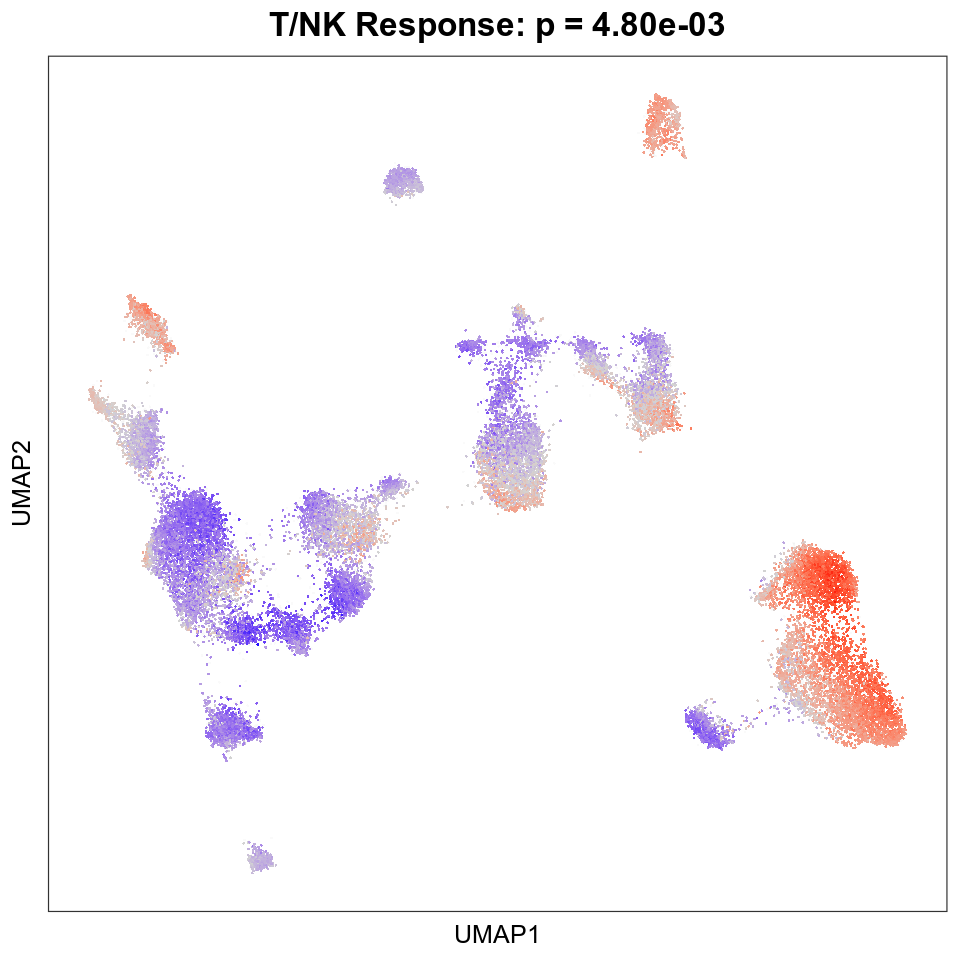

In [107]:
fdr_10 <- fdrs %>% filter(fdr < 0.1) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr_10, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)


fig.size(8, 8)
ggplot() + 
      geom_point(data = qcd_meta, 
                     aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', alpha = 0.1, size = 0.75, stroke = 0.00001) +
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001) +  
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
      labs(x="UMAP1", y="UMAP2", title = "T/NK Response: p = 4.80e-03") +
      theme_bw(base_size = 15) +
  theme( legend.position = "none",
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(color="black", hjust = 0.5, face = "bold", size=20)
  ) 

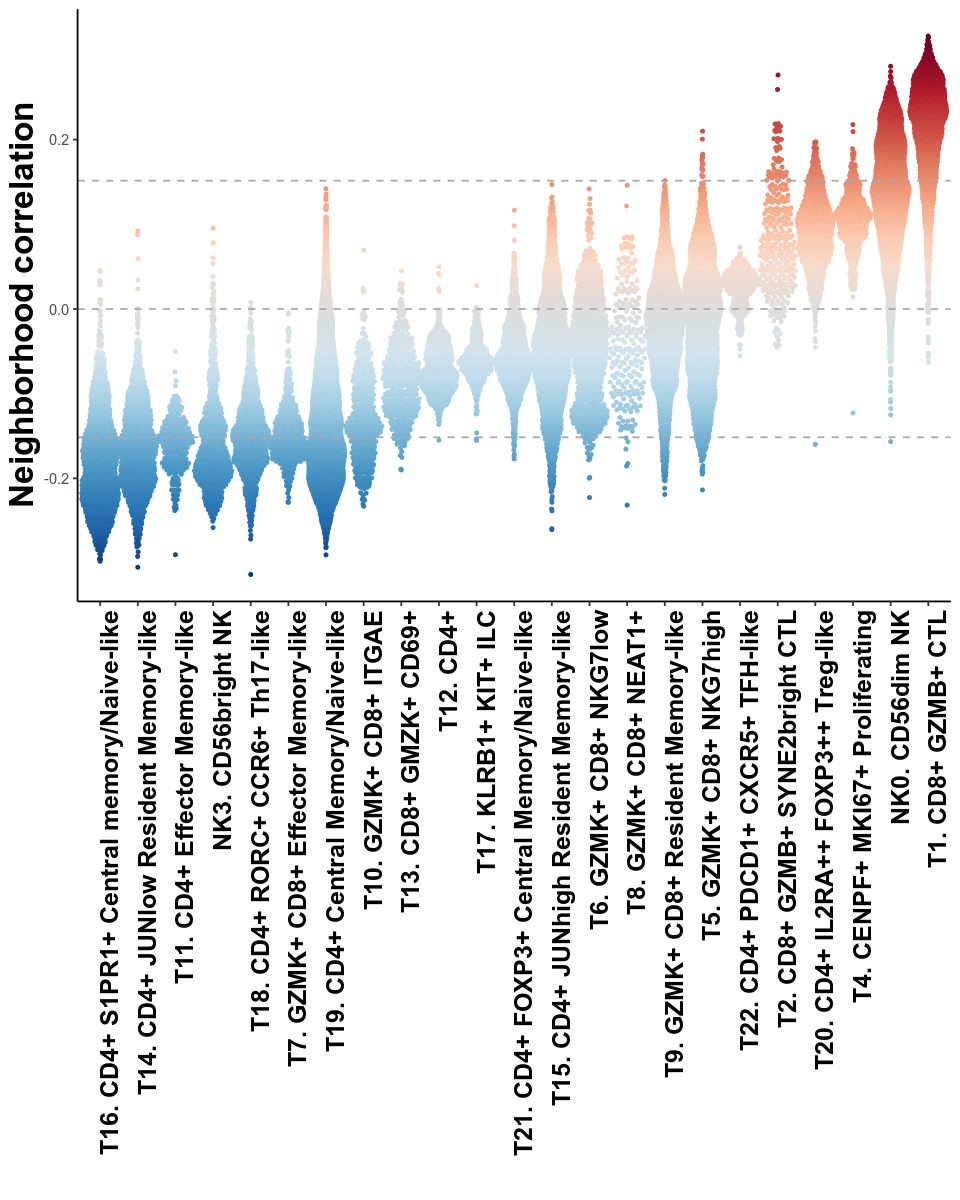

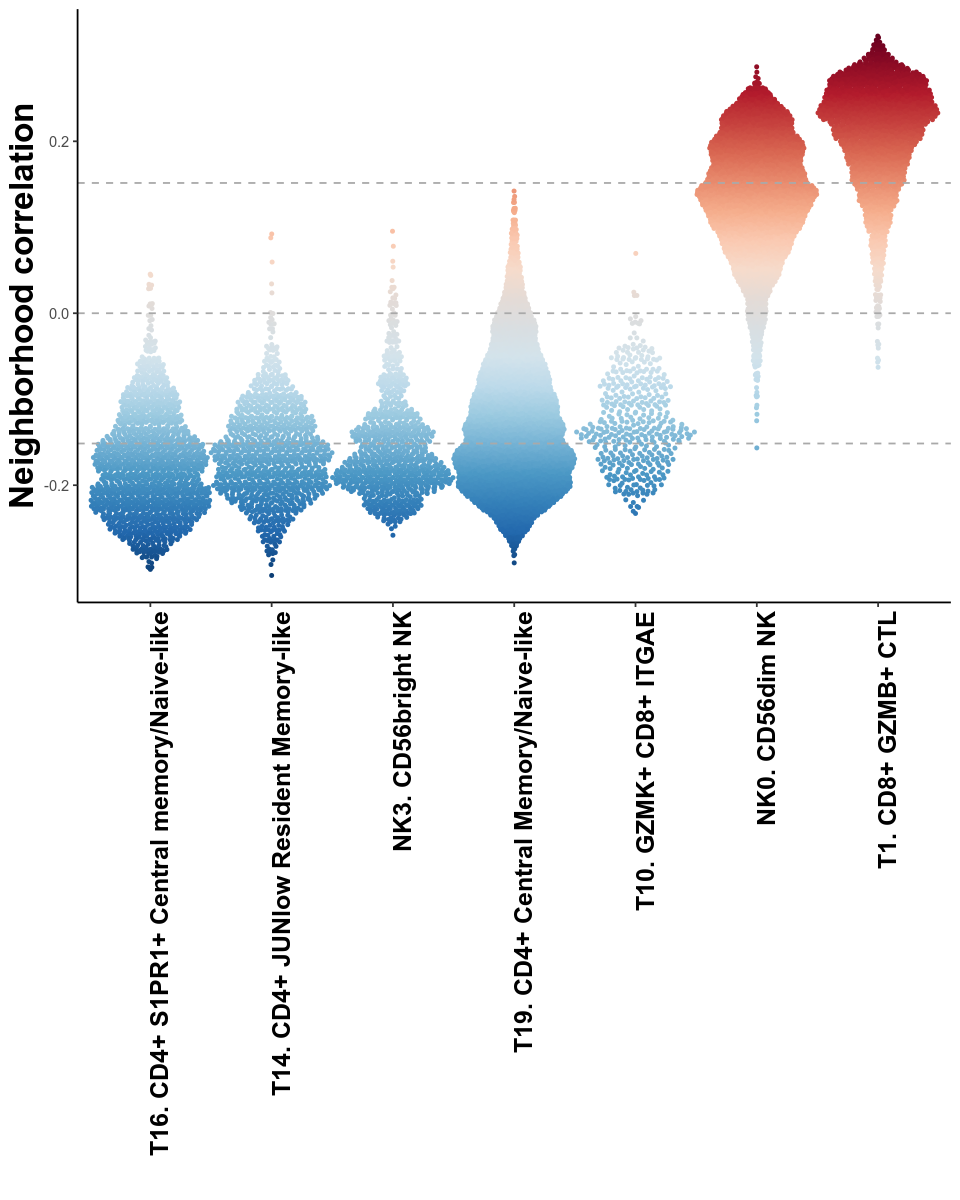

In [74]:
pos_fdr_thresh <- fdr_10
neg_fdr_thresh <- -1 * fdr_10

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
fig.size(10, 8)

ggplot(meta, aes(x = reorder(final_annotation, ncorr), y = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.5, size = 0.75) +
    geom_hline(yintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
    labs( x= "", y = "Neighborhood correlation") +
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        plot.title = element_text(color="black", size=22, face = "bold"),
        axis.text.x = element_text(color = "black", size = 15, angle = 90, hjust=1, face = "bold"),
        axis.title = element_text(size=20, face = "bold"))

ggplot(meta %>% filter(final_annotation %in% c('T16. CD4+ S1PR1+ Central memory/Naive-like',
                                               'T14. CD4+ JUNlow Resident Memory-like',
                                               'NK3. CD56bright NK',
                                               'T19. CD4+ Central Memory/Naive-like',
                                               'T10. GZMK+ CD8+ ITGAE',
                                               'NK0. CD56dim NK',
                                               'T1. CD8+ GZMB+ CTL')), aes(x = reorder(final_annotation, ncorr), y = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.5, size = 0.75) +
    geom_hline(yintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
    labs( x= "", y = "Neighborhood correlation") +
    scale_x_discrete(limits = c('T16. CD4+ S1PR1+ Central memory/Naive-like',
                                               'T14. CD4+ JUNlow Resident Memory-like',
                                               'NK3. CD56bright NK',
                                               'T19. CD4+ Central Memory/Naive-like',
                                                'T10. GZMK+ CD8+ ITGAE',
                                               'NK0. CD56dim NK',
                                               'T1. CD8+ GZMB+ CTL')) + 
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        plot.title = element_text(color="black", size=22, face = "bold"),
        axis.text.x = element_text(color = "black", size = 15, angle = 90, hjust=1, face = "bold"),
        axis.title = element_text(size=20, face = "bold"))

In [4]:
pt_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_meta_response.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_umap_response.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_injured_pt_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_injured_pt_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
pt_meta$ncorr <- ncorr$V1


meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_meta_response.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_umap_response.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_response_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/age_sex_response_race/sc_response_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

chron_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_covariate_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_covariate_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
chron_meta$ncorr <- ncorr$V1

Joining, by = "cell"


[1] -0.8289712

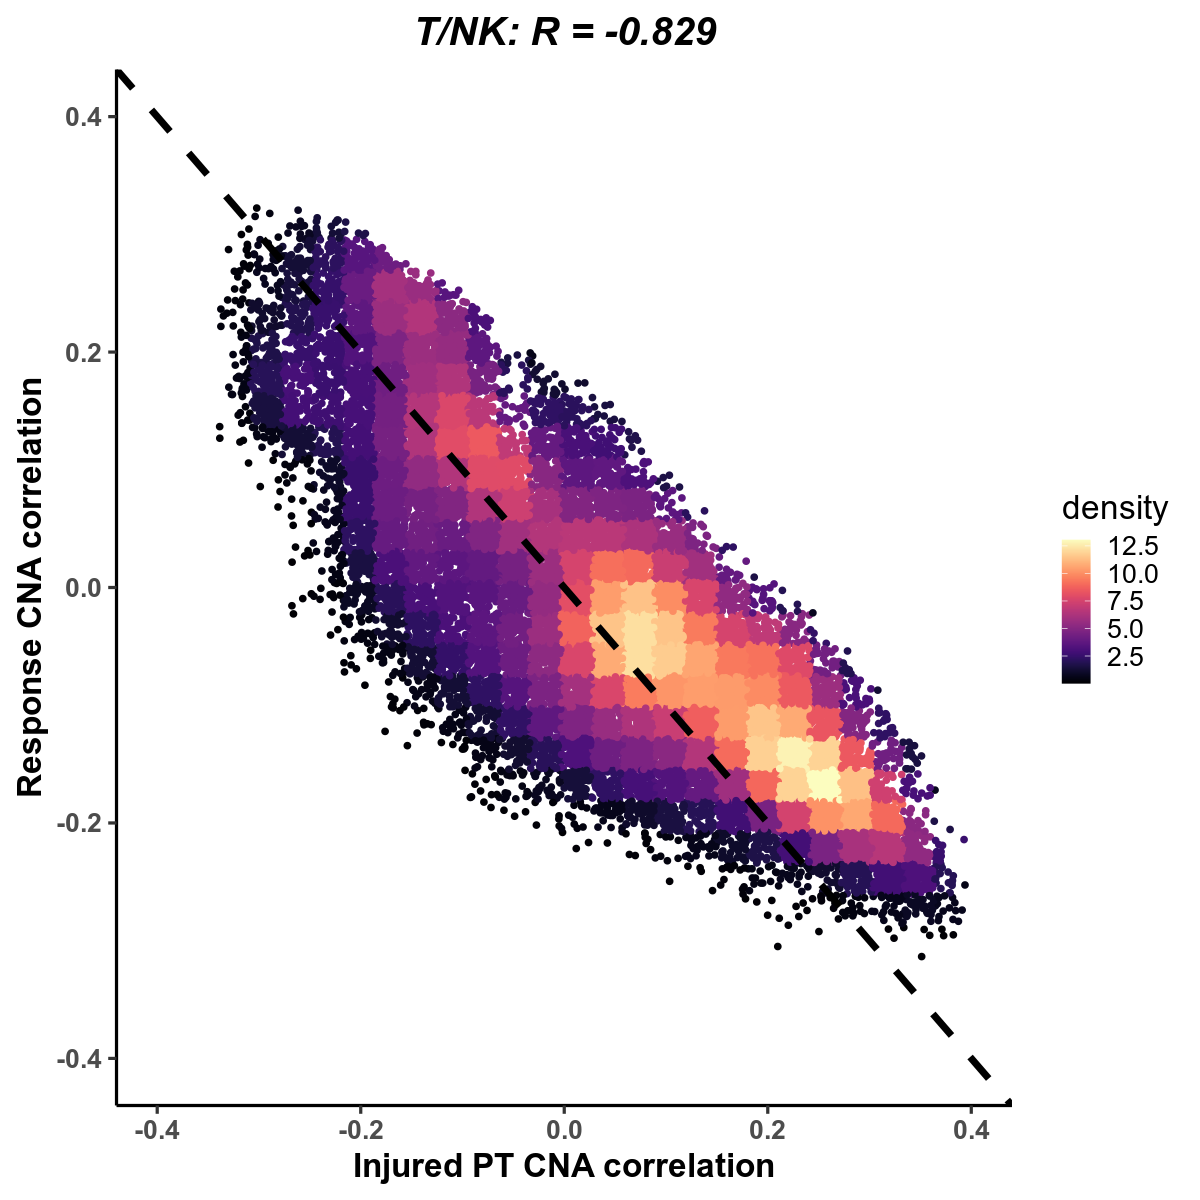

In [19]:
ncorr_meta <- pt_meta %>% 
                    select(cell, ncorr) %>% 
                    rename(pt_ncorr = ncorr) %>% 
                left_join(meta %>% 
                            select(cell, ncorr) %>% 
                            rename(chronicity_ncorr = ncorr)) %>% na.omit()

get_density <- function(x, y, ...) {
  dens <- MASS::kde2d(x, y, ...)
  ix <- findInterval(x, dens$x)
  iy <- findInterval(y, dens$y)
  ii <- cbind(ix, iy)
  return(dens$z[ii])
}

ncorr_meta$density <- get_density(ncorr_meta$pt_ncorr, ncorr_meta$chronicity_ncorr)

fig.size(10, 10)
cor(ncorr_meta$pt_ncorr, ncorr_meta$chronicity_ncorr)
ggplot(ncorr_meta, aes(x = pt_ncorr, y = chronicity_ncorr, color = density)) +
    geom_point() +
    scale_color_viridis(option = "magma") + 
    theme_classic(base_size = 20) +
    geom_abline(slope = -1, linetype = 'dashed', linewidth = 2) + 
    scale_x_continuous(limits = c(-0.4, 0.4)) + 
    scale_y_continuous(limits = c(-0.4, 0.4)) + 
    labs(x = "Injured PT CNA correlation",
         y = "Response CNA correlation",
         title = "T/NK: R = -0.829") + 
    theme(
          axis.text = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold.italic", 
                                    hjust = 0.5))

Joining, by = "cell"


[1] -0.8078947

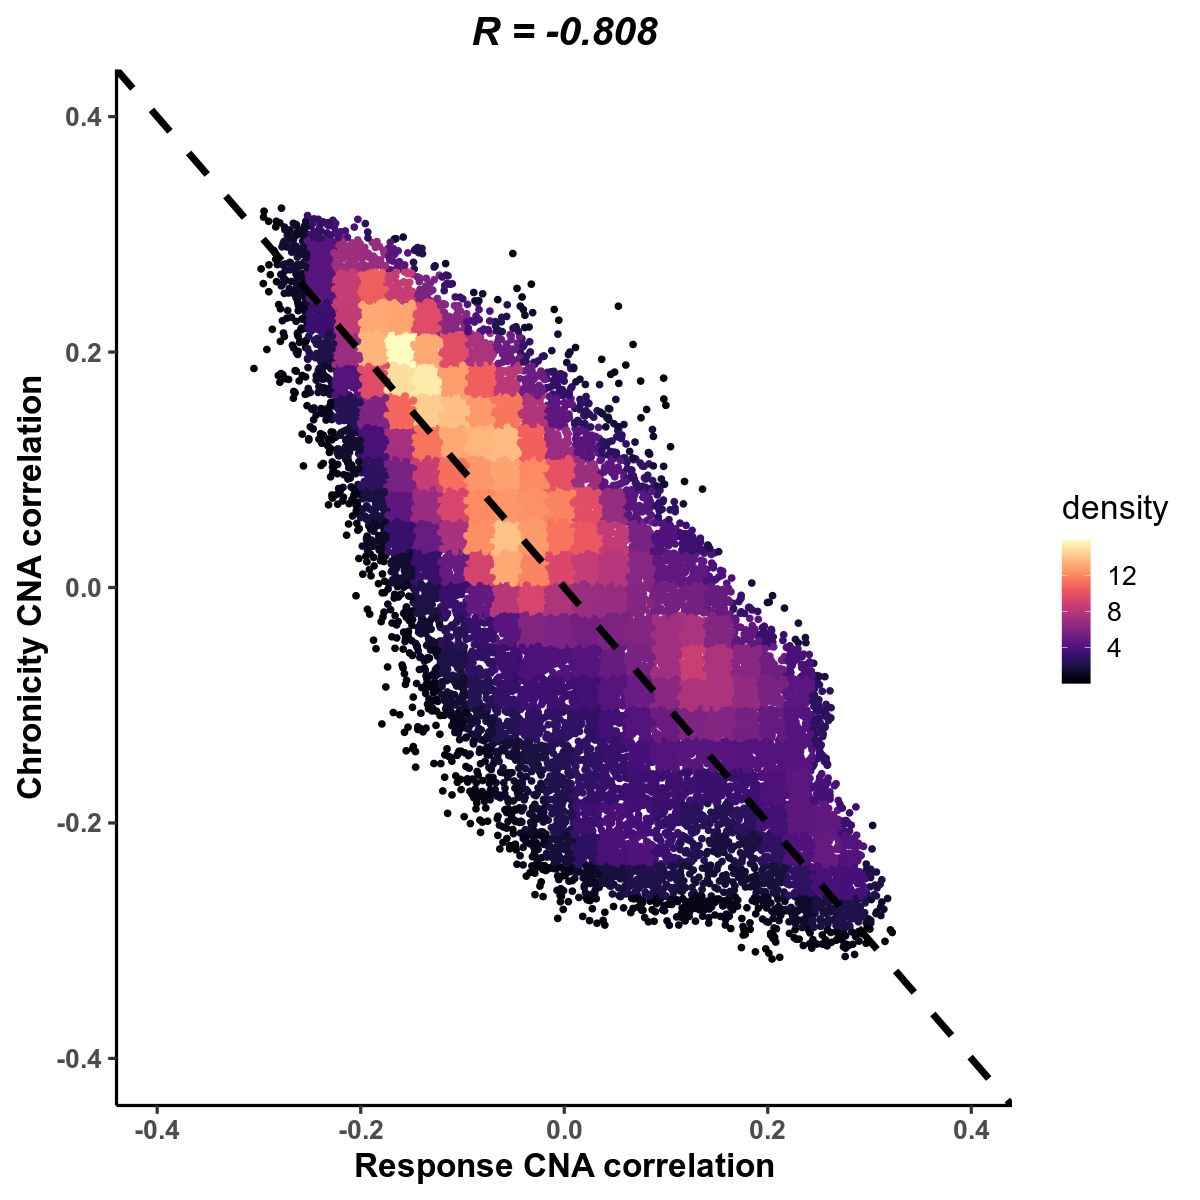

In [7]:
ncorr_meta <- chron_meta %>% 
                    select(cell, ncorr) %>% 
                    rename(chronicity_ncorr = ncorr) %>% 
                left_join(meta %>% 
                            select(cell, ncorr) %>% 
                            rename(response_ncorr = ncorr)) %>% na.omit()

get_density <- function(x, y, ...) {
  dens <- MASS::kde2d(x, y, ...)
  ix <- findInterval(x, dens$x)
  iy <- findInterval(y, dens$y)
  ii <- cbind(ix, iy)
  return(dens$z[ii])
}

ncorr_meta$density <- get_density(ncorr_meta$chronicity_ncorr, ncorr_meta$response_ncorr)

fig.size(10, 10)
cor(ncorr_meta$response_ncorr, ncorr_meta$chronicity_ncorr)
ggplot(ncorr_meta, aes(x = response_ncorr, y = chronicity_ncorr, color = density)) +
    geom_point() +
    scale_color_viridis(option = "magma") + 
    theme_classic(base_size = 20) +
    geom_abline(slope = -1, linetype = 'dashed', linewidth = 2) + 
    scale_x_continuous(limits = c(-0.4, 0.4)) + 
    scale_y_continuous(limits = c(-0.4, 0.4)) + 
    labs(x = "Response CNA correlation",
         y = "Chronicity CNA correlation",
         title = "R = -0.808") + 
    theme(
          axis.text = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          plot.title = element_text(face = "bold.italic", 
                                    hjust = 0.5))

### Chronicity

In [22]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Chronicity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [23]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Chronicity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


#### Results - NO CONDITIONING

In [39]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

#### MASC

In [ ]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_Chronicity",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", "percent.mt"),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

In [596]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/chronicity.rds')

In [597]:
res <- res %>% 
        rowwise() %>% 
        mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(0, 3), 
                                paste0('NK', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('T', unlist(str_split(cluster, 'cluster'))[2])))

Warning message:
“Removed 20 rows containing missing values (`geom_label_repel()`).”


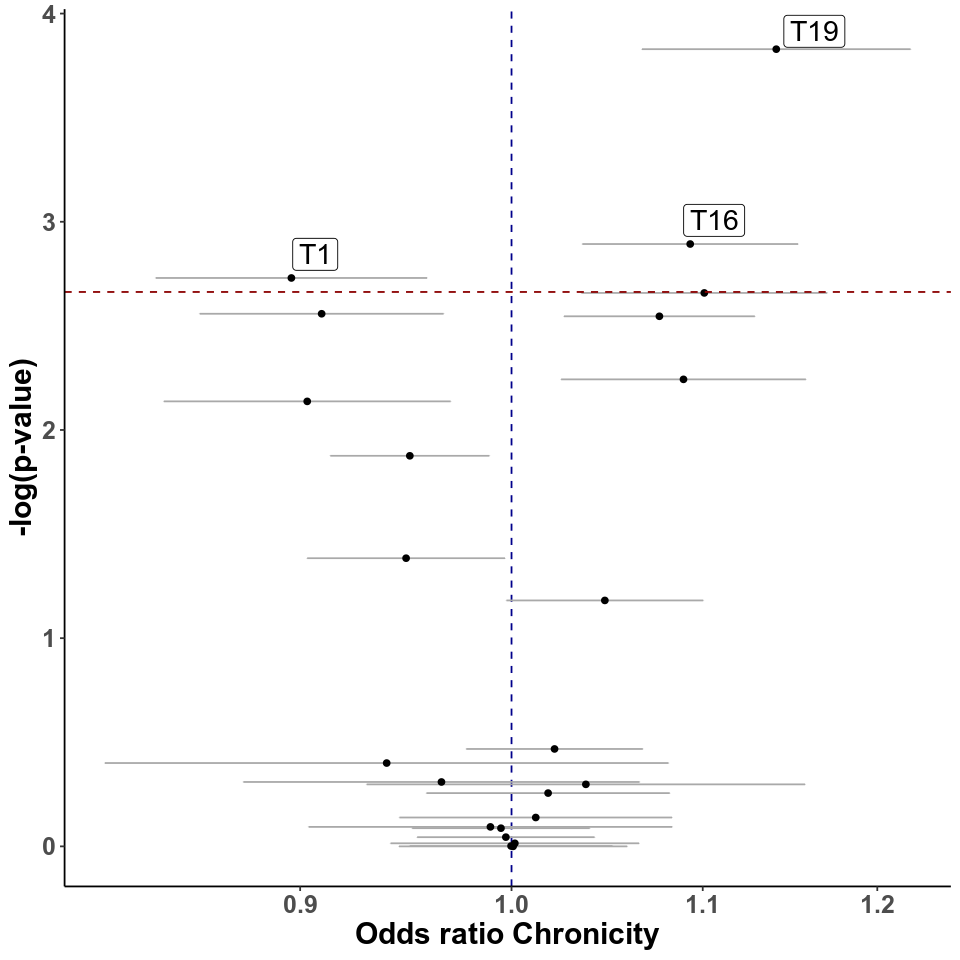

In [608]:
fig.size(8, 8)
ggplot(data = res %>% mutate(label = ifelse(-log10(model.pvalue) > -log10(0.05/23), cluster, NA)), 
       aes(x = Final_Chronicity.OR, y = -log10(model.pvalue))) +
    theme_classic() + ylab("-log(p-value)") + xlab("Odds ratio Chronicity") +
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=Final_Chronicity.OR.95pct.ci.lower	, xmax=Final_Chronicity.OR.95pct.ci.upper), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(.05/ 23), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.8, 0.9, 1, 1.1, 1.2)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6) +
    theme(axis.title = element_text(size = 18, face = "bold"),
          axis.text = element_text(size = 15, face = "bold"))

#### CNA

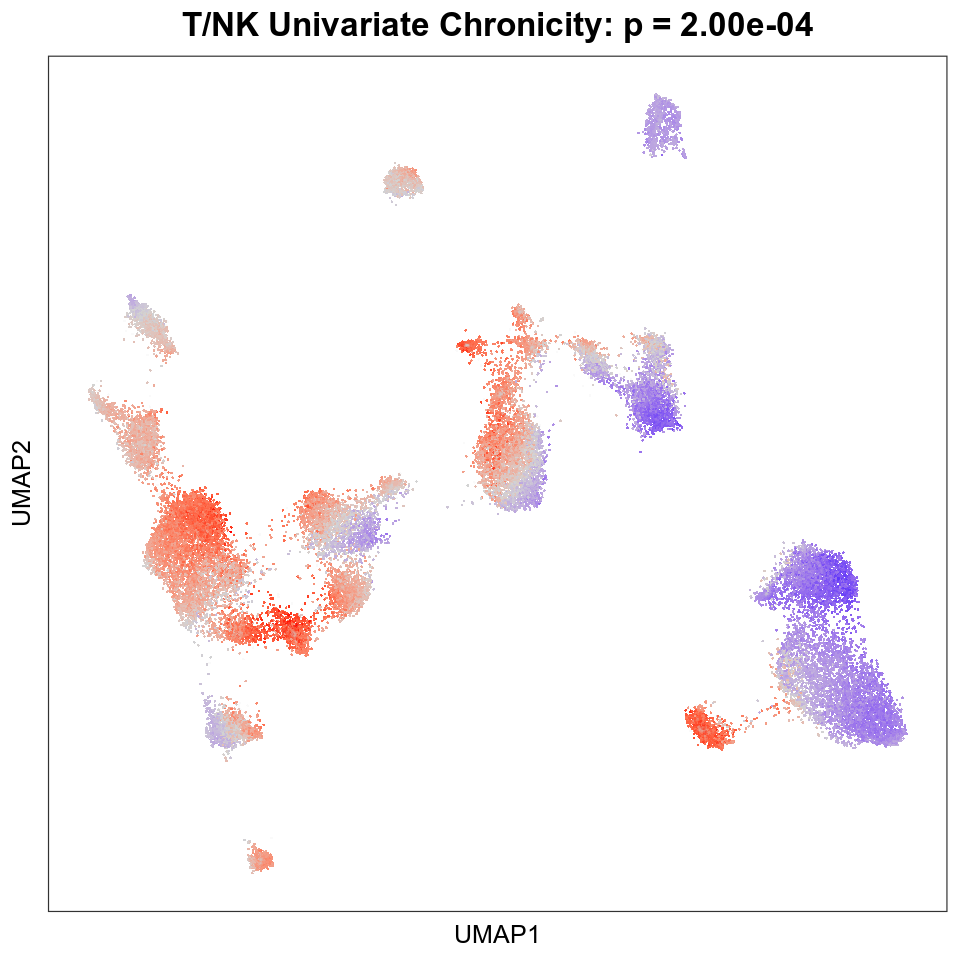

In [40]:
fdr_10 <- fdrs %>% filter(fdr < 0.1) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr_10, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
ggplot() + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.00001) + 
      geom_point(data = qcd_meta %>% filter(dataset == 'snRNAseq'),
                     aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', alpha = 0.1, size = 0.75, stroke = 0.00001) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
      labs(x="UMAP1", y="UMAP2", title = "T/NK Univariate Chronicity: p = 2.00e-04") +
      theme_bw(base_size = 15) +
  theme( legend.position = "none",
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(color="black", hjust = 0.5, face = "bold", size=20)
  ) 

In [480]:
clusters <- qcd_meta %>% 
                           filter(new_cluster_number %in% c(0, 1, 2, 5, 6, 3, 14, 16, 17, 19)) %>% 
                       pull(final_annotation) %>% unique()

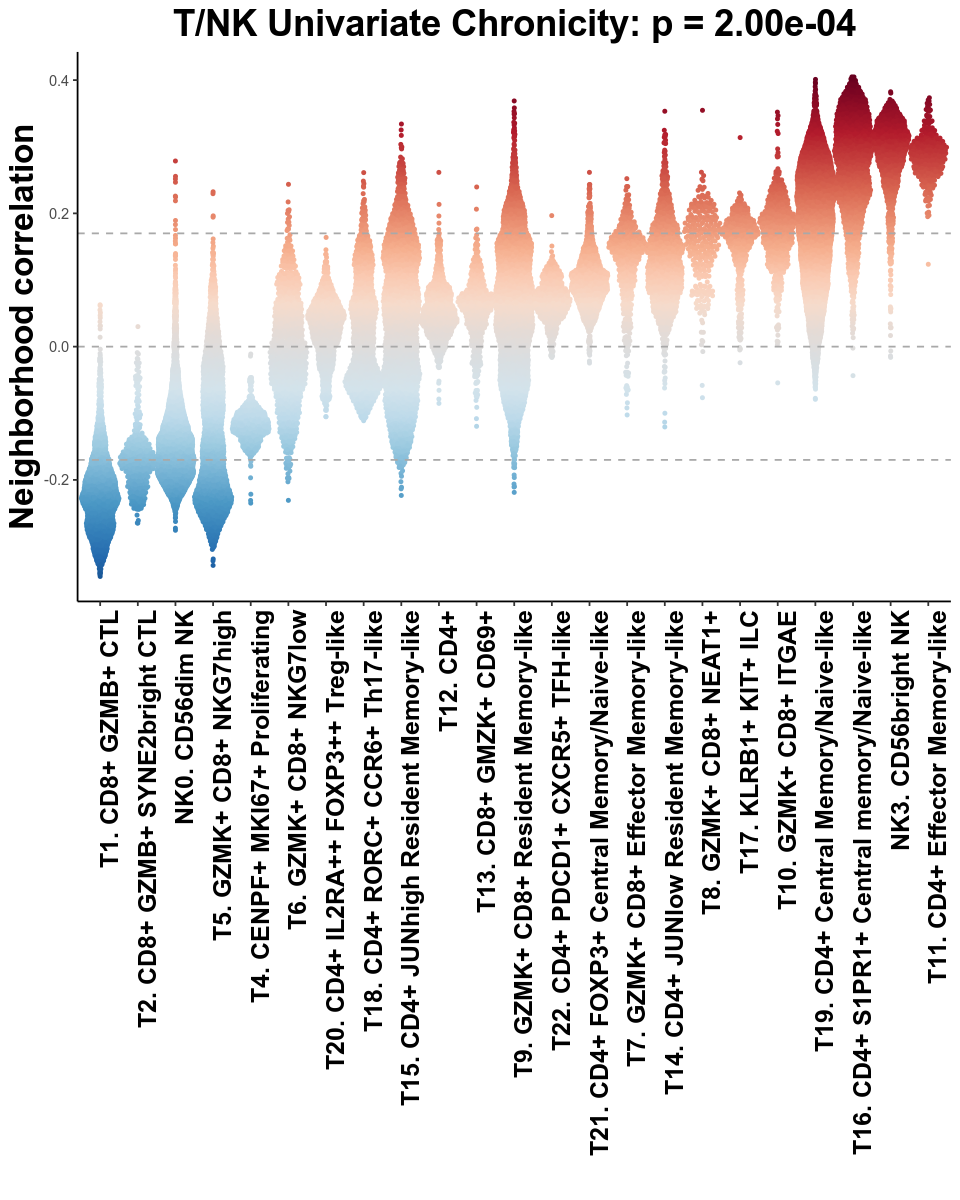

In [30]:
pos_fdr_thresh <- fdr_10
neg_fdr_thresh <- -1 * fdr_10

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
fig.size(10, 8)

cluster_order <- meta %>% select(final_annotation, ncorr) %>% group_by(final_annotation) %>% summarize(ncorr = mean(ncorr)) %>% arrange(ncorr) %>% pull(final_annotation)

ggplot(meta, aes(x = reorder(final_annotation, ncorr), y = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.5, size = 0.75) +
    geom_hline(yintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
    labs( x= "", y = "Neighborhood correlation", title = "T/NK Univariate Chronicity: p = 2.00e-04") +
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        plot.title = element_text(color="black", size=22, face = "bold", hjust = 0.5),
        axis.text.x = element_text(color = "black", size = 15, angle = 90, hjust=1, face = "bold"),
        axis.title = element_text(size=20, face = "bold"))

In [ ]:
ggplot(meta %>% filter(final_annotation %in% clusters), aes(x = reorder(final_annotation, ncorr), y = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.5, size = 0.75) +
    geom_hline(yintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
    labs( x= "", y = "Neighborhood correlation") +
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        plot.title = element_text(color="black", size=22, face = "bold"),
        axis.text.x = element_text(color = "black", size = 15, angle = 90, hjust=1, face = "bold"),
        axis.title = element_text(size=20, face = "bold"))

#### Results - CONDITIONING

In [94]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

In [107]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

ci_summary <- meta %>% left_join(qcd_meta %>% select(cell, new_cluster_number)) %>% 
                select(new_cluster_number, cell, ncorr) %>% 
                group_by(new_cluster_number) %>% 
                summarize(ncorr.ci = paste0("(", round(mean(ncorr) - 1.96 * sd(ncorr) / sqrt(length(cell)), 3),
                                      ", ", round(mean(ncorr) + 1.96 * sd(ncorr) / sqrt(length(cell)), 3), ")"))
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/chronicity_covariates.rds') %>% 
        mutate(new_cluster_number = as.numeric(str_remove(cluster, "cluster")),
               OR.ci = paste0("(", round(Final_Chronicity.OR.95pct.ci.lower, 3), ", ", 
                              round(Final_Chronicity.OR.95pct.ci.upper, 3), ")")) %>% 
        select(new_cluster_number, OR.ci)

summary <- ci_summary %>% left_join(res)
write.table(summary, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/tnk_chronicity_corr_04152024.csv', quote = FALSE, row.names = FALSE,
            sep = "\t")

Joining, by = "cell"
Joining, by = "new_cluster_number"


#### MASC

In [3]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')

In [8]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_Chronicity",
                random_effects = c("sample"),
                fixed_effects = c('nCount_RNA', 'percent.mt', 'First_biop', 'Responder_Status'),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Joining, by = "cell"
Using null model: cluster ~ nCount_RNA + percent.mt + First_biop + Responder_Status + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Creating logistic mixed models for cluster19

Creating logistic mixed models for cluster2

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0950231 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable

In [9]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/chronicity_covariates.rds')

In [10]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/chronicity_covariates.rds')

In [11]:
res <- res %>% 
        rowwise() %>% 
        mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(0, 3), 
                                paste0('NK', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('T', unlist(str_split(cluster, 'cluster'))[2])))

In [13]:
fig.size(8, 8)
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = Final_Chronicity.OR, y = -log10(model.pvalue))) +
                theme_classic() + ylab("-log10(p-value)") + xlab("Odds ratio Chronicity") +
                geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=Final_Chronicity.OR.95pct.ci.lower, xmax=Final_Chronicity.OR.95pct.ci.upper), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                scale_x_log10(breaks = c(0.6, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = 18, face = "bold"),
                      axis.text = element_text(size = 15, face = "bold"),
                     text=element_text(family="Arial"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure3/tnk_masc.png",
       masc_plot,
       base_height = 8,
       base_width = 8)
masc_plot

Warning message:
“Removed 14 rows containing missing values (`geom_label_repel()`).”
Warning message:
“Removed 14 rows containing missing values (`geom_label_repel()`).”


ERROR: Error in value[[3L]](cond): could not open file '/tmp/1631.tmpdir/RtmpG365kA/file4be3471a8593b.png'


plot without title

#### CNA

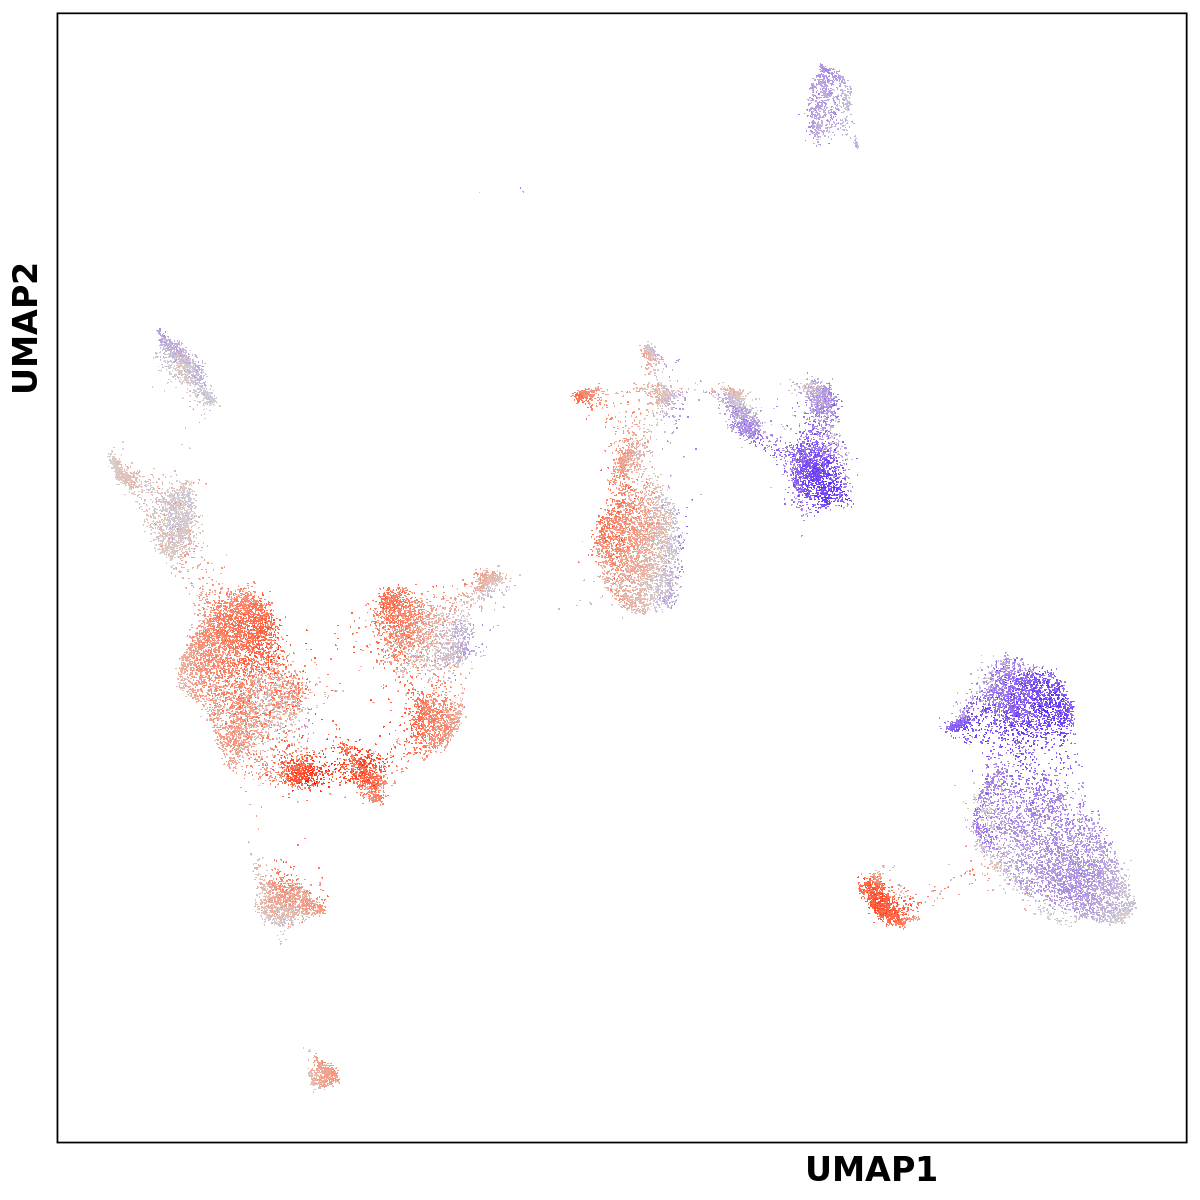

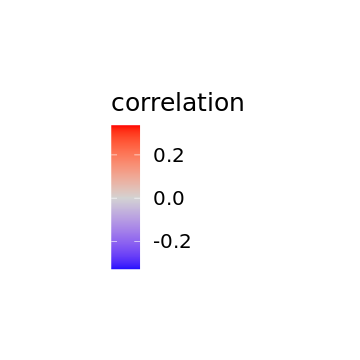

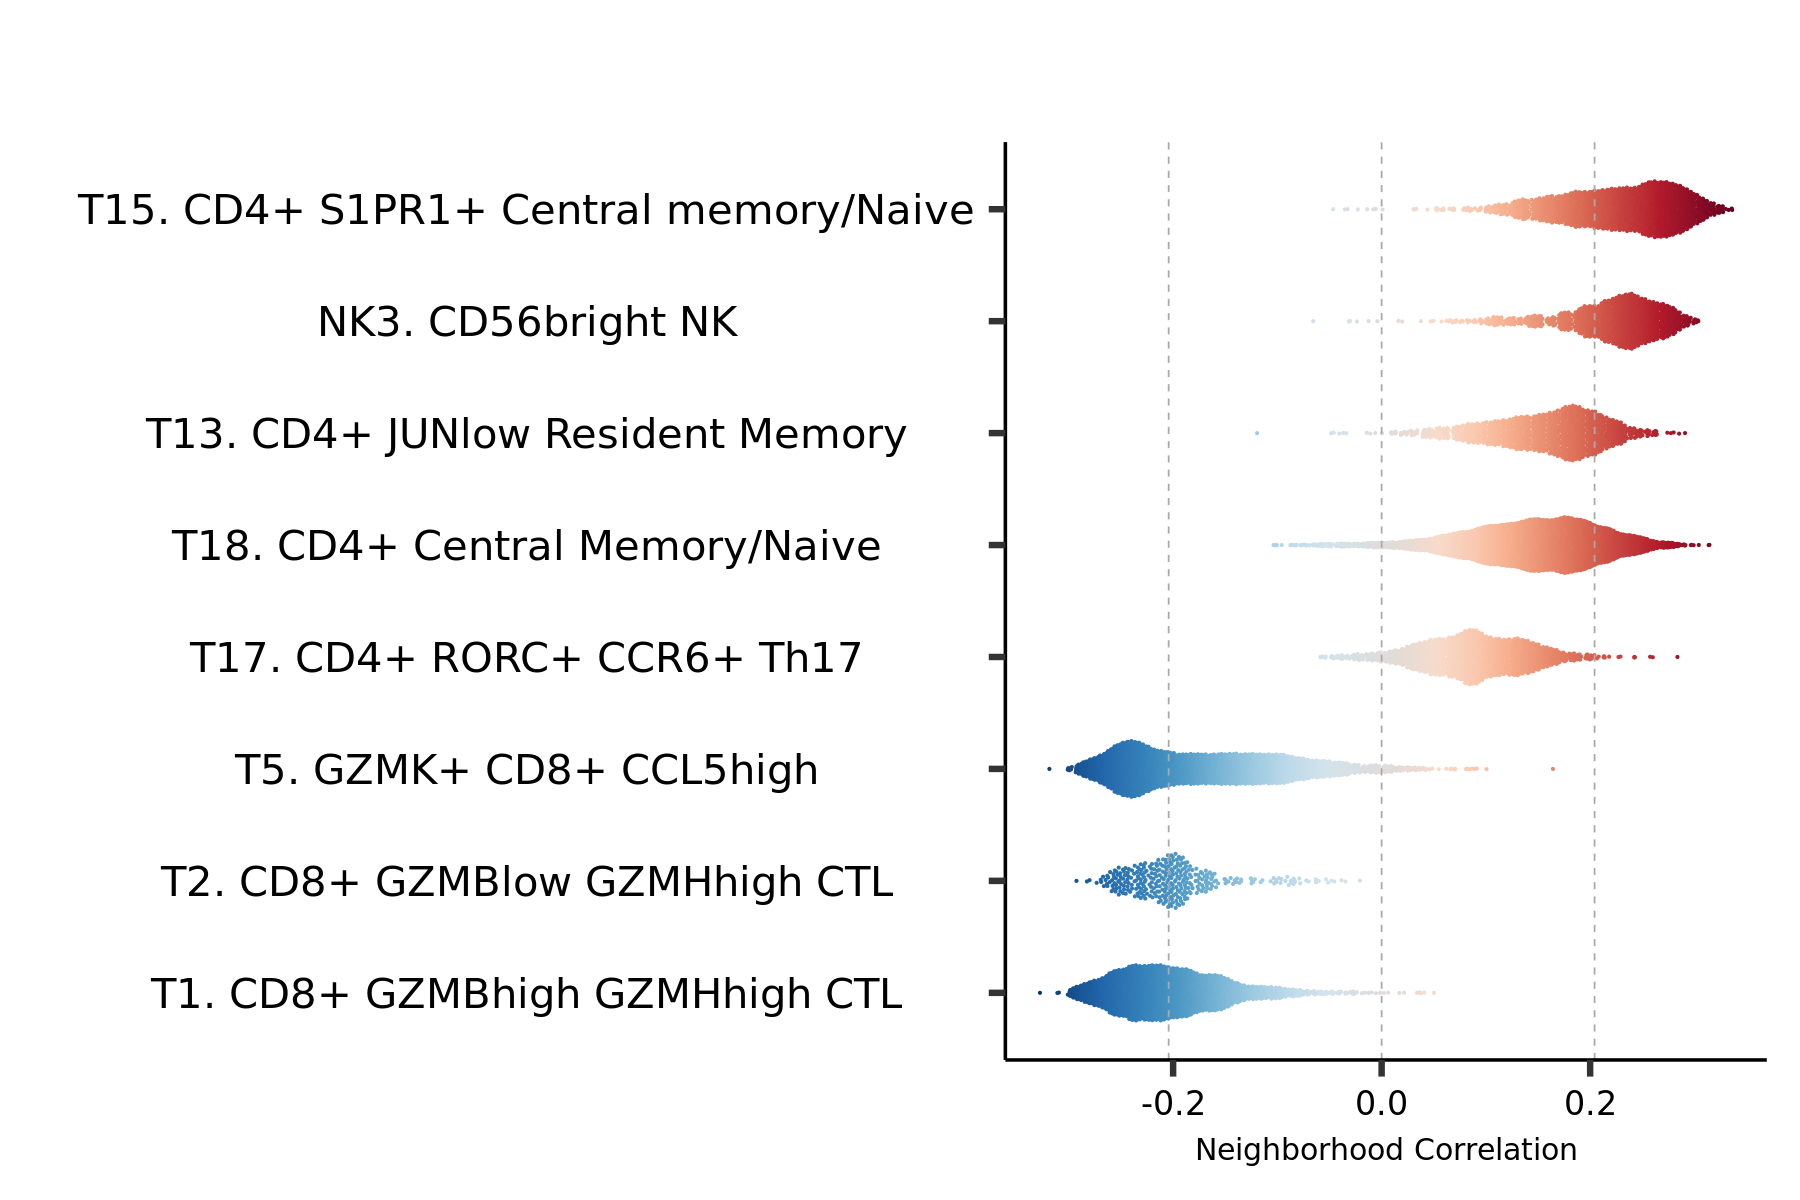

In [6]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
harmony <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_harmony.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')

fdrs <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_fdrs.csv', header = FALSE)
ncorr <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_ncorr.csv', header = FALSE)

colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/tnk_cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/tnk_cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
subset <- c(1, 2, 3, 5, 13, 15, 17, 18)


violin_plot <- ggplot(meta %>% filter(new_cluster_number %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = 40) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                        axis.line.y.left   = element_line(color = 'black', linewidth = 1))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/tnk_violin_plot.png",
       violin_plot,
       base_height = 10,
       base_width = 15)
fig.size(10, 15)
violin_plot

options(warn=0)

#### DE

In [48]:
de <- function(feature, df) {
    model_df <- df %>% select(feature, sample, First_biop, Responder_Status, 
                              Final_Chronicity, avg_count, avg_mt) %>% rename(Exp = feature)
    if (sum(model_df$Exp > 0) > 0.05 * nrow(model_df)) { 
        m_0 <- lm(Exp ~ log(avg_count) + avg_mt, data = model_df)
        m_1 <- lm(Exp ~ log(avg_count) + avg_mt + Final_Chronicity, data = model_df)
        ANNO <- anova(m_0, m_1)
        LRP <- ANNO[2,6]
        F <- ANNO[2,5]
        Beta <- summary(m_1)$coefficients['Final_Chronicity', 'Estimate']
        SE <- summary(m_1)$coefficients['Final_Chronicity', 'Std. Error']
        res <- c(gene = feature, LRP = LRP, F = F, Beta = Beta, SE = SE)
    }
    else {
        res <- c(gene = feature, LRP = NA, F = NA, Beta = NA, SE = NA)
    }
    return(res)
}

In [4]:
tnk_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_norm_pseudobulk_12072023.rds')
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')

In [5]:
tnk_pb <- tnk_pb %>% 
                filter(sample %in% unique(meta$sample)) %>% 
                left_join(meta %>% 
                              select(sample, First_biop, Responder_Status, Final_Chronicity) %>% 
                              unique())

Joining, by = "sample"


In [49]:
de_out <- mclapply(colnames(tnk_pb)[1:36601], de, tnk_pb, mc.cores = 20)

In [64]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [71]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_chronicity_differential_expression_03082024.rds')

In [135]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/TNK_chronicity_differential_expression_03082024.rds')

In [136]:
de_df <- de_df %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) 

In [129]:
genes <- c("CX3CR1", "MMP7", "WFDC2", "NKG7", "GZMA",
           "IL7R", "CCL5", "MIOX", "LGALS1", "GSTA1")

Warning message:
“Removed 21726 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


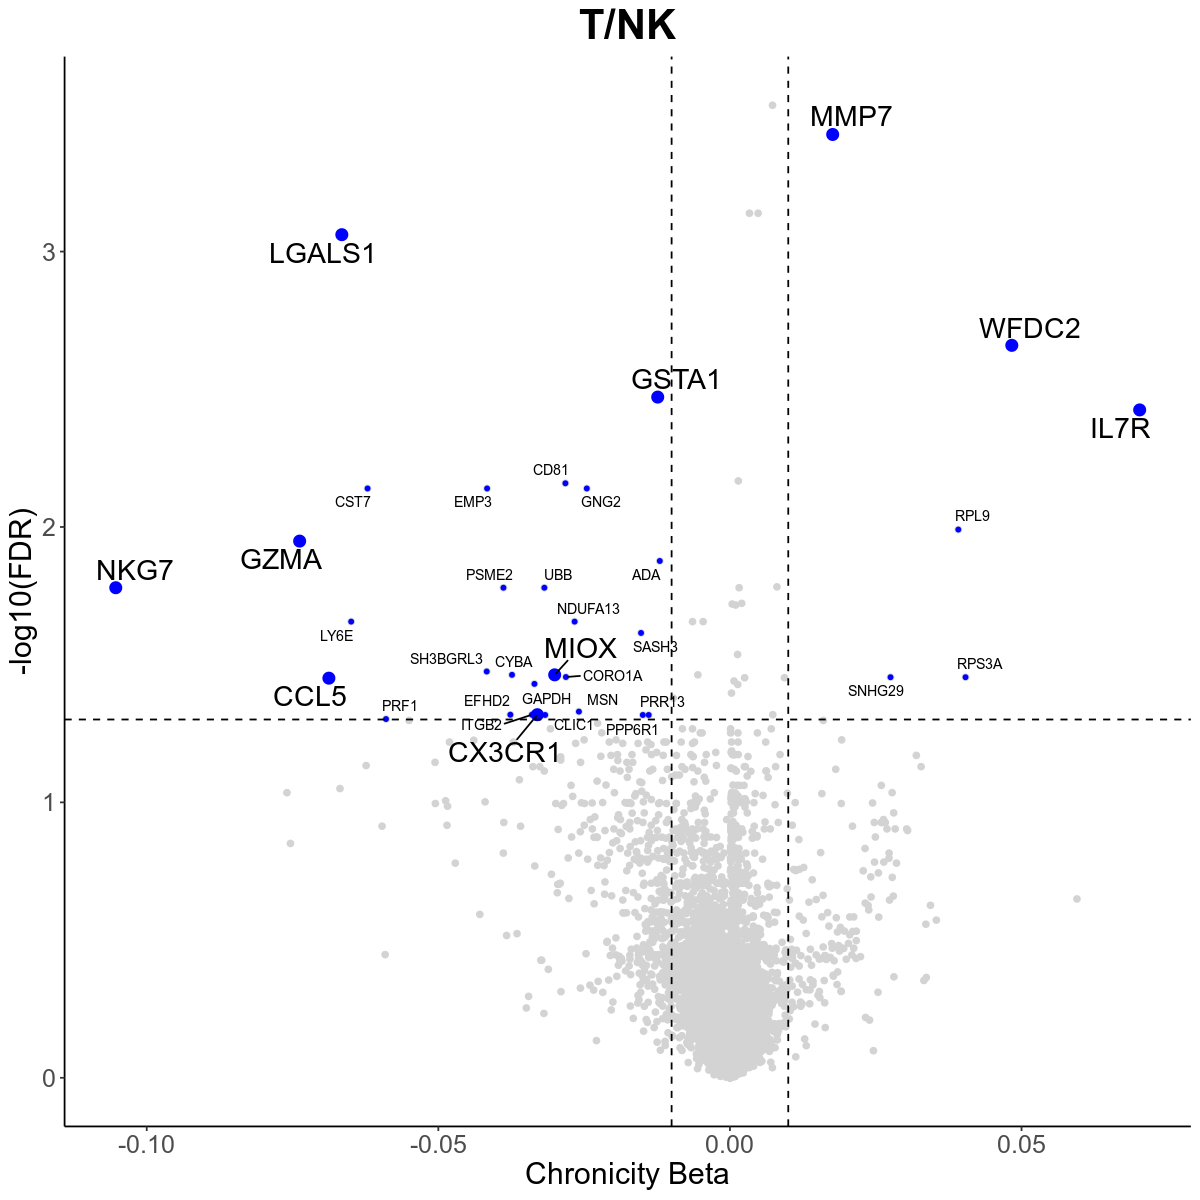

In [130]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(FDR))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(FDR < 0.05 & abs(Beta) >= 0.01,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.01, 0.01), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
    theme_classic() + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(FDR<0.05 & abs(Beta) >= 0.01 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(FDR), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Chronicity Beta", y = "-log10(FDR)", title = "T/NK")

In [5]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')
qcd_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_norm_09092022.rds')
meta <- meta %>% cbind(umap)

In [151]:
ncorr <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_ncorr.csv', header = FALSE)

In [153]:
meta$ncorr <- ncorr$V1

In [168]:
cor.test(qcd_norm['ISG15', meta$cell], meta$ncorr)


	Pearson's product-moment correlation

data:  qcd_norm["ISG15", meta$cell] and meta$ncorr
t = -32.853, df = 31559, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1924980 -0.1711625
sample estimates:
       cor 
-0.1818517 


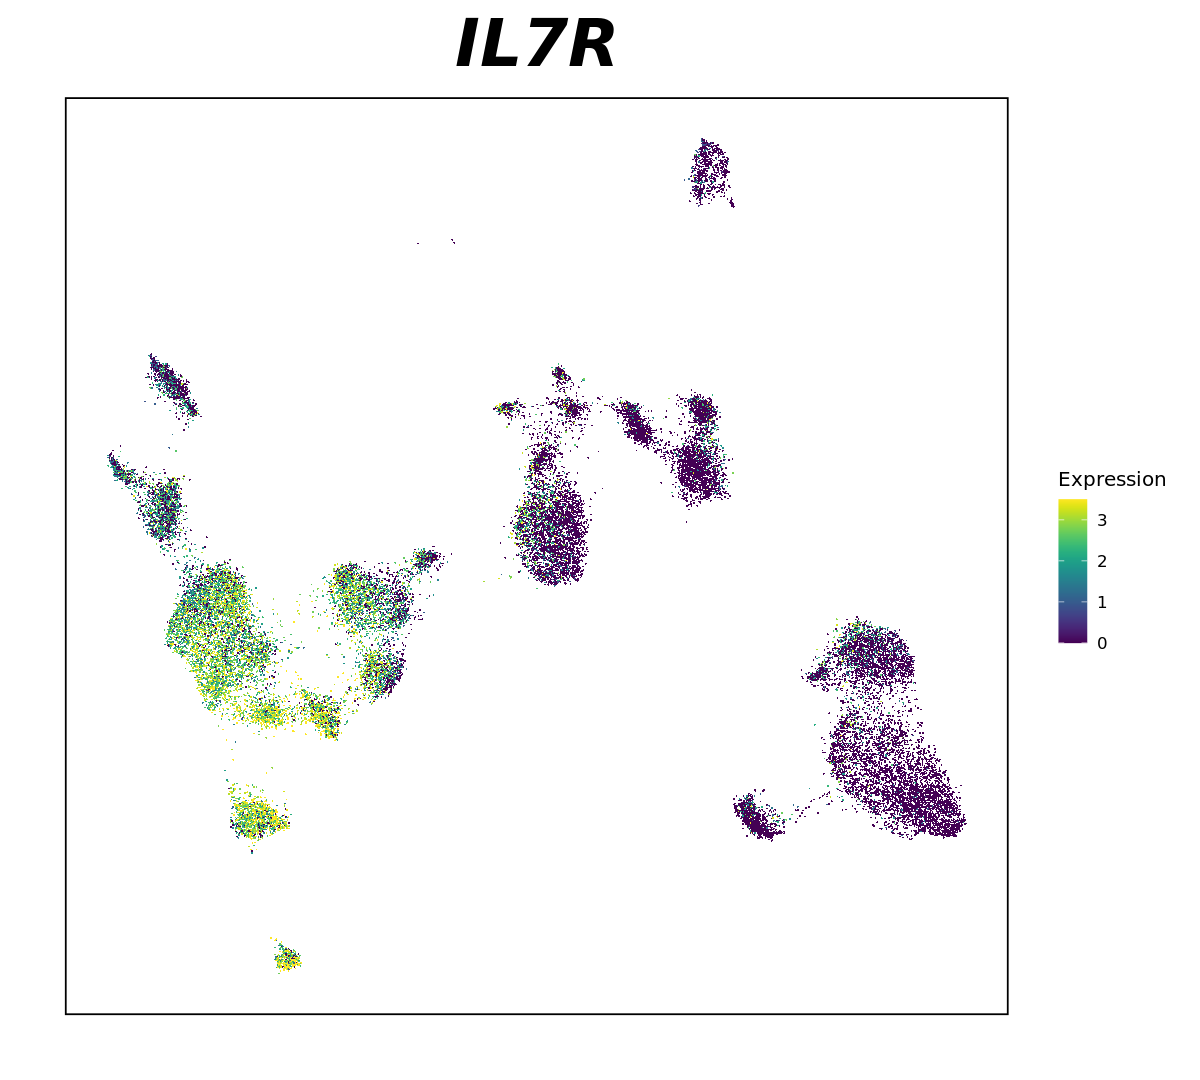

In [30]:
meta <- meta %>% cbind(umap)
fig.size(9, 10)
plot_shuffled_features(meta, 
                       qcd_norm, "IL7R", 
                       pct = 0.95,  
                       pt_size = 0.75) + 
    theme(plot.title = element_text(size = 40),
                    panel.border = element_rect(colour = "black", fill=NA, size=1)) 

In [8]:
meta <- cbind(meta, umap)

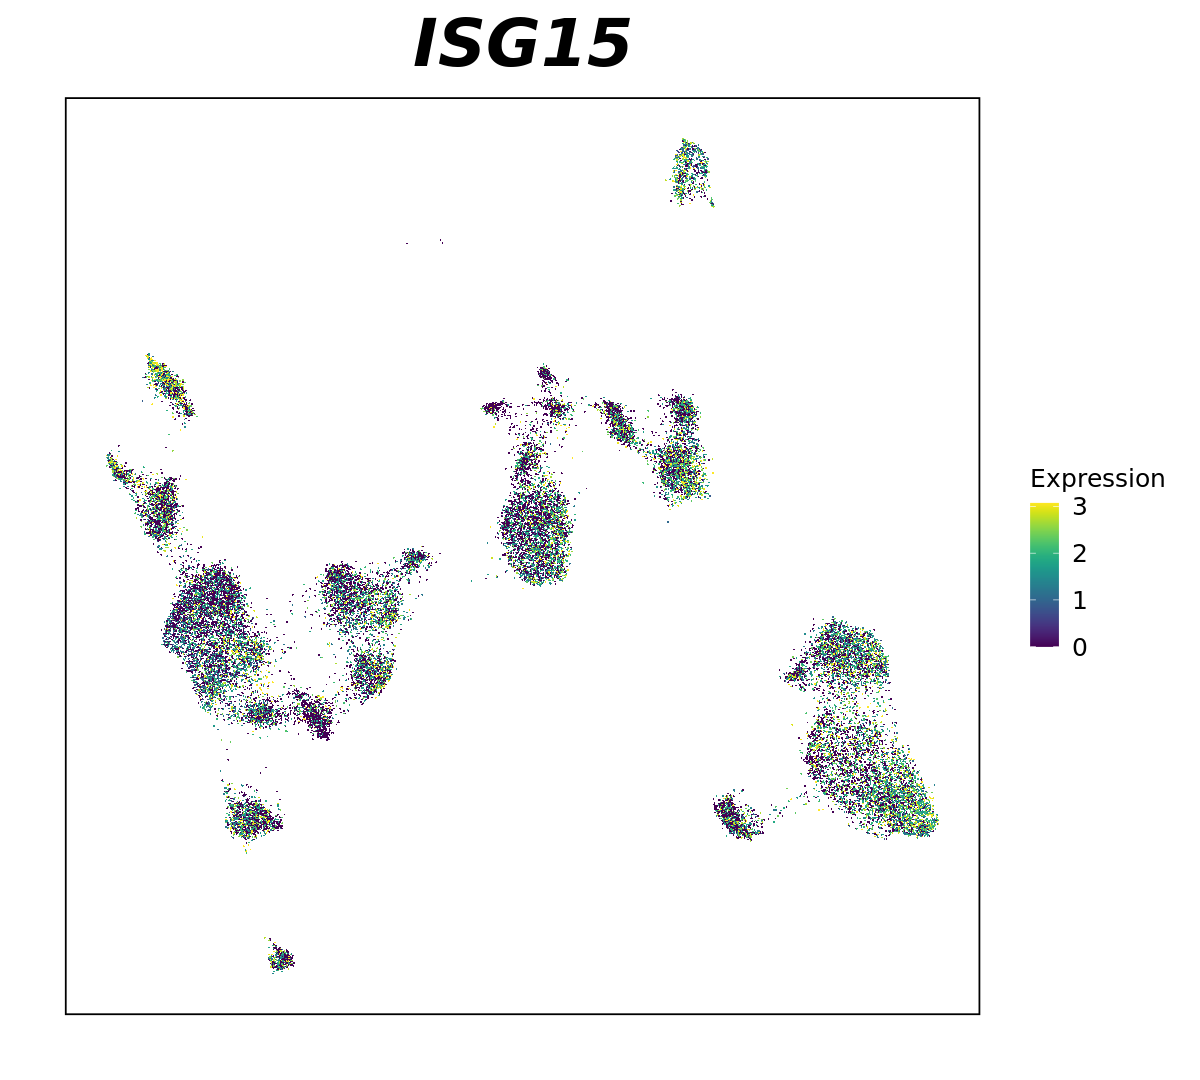

In [11]:
fig.size(9, 10)
p <- plot_shuffled_features(meta, 
                       qcd_norm, 
                       "ISG15", 
                       pct = 0.95, 
                       pt_size = 0.75) + 
    theme(plot.title = element_text(size = 40),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          legend.text = element_text(size = 15),
          legend.title = element_text(size = 15))
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/tnk_isg_plot.png",
       p,
       base_height = 9,
       base_width = 10)
p

#### ISG Score Chronicity

In [2]:
genes <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/isg_genes.rds')
tnk_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/TNK_norm_pseudobulk_12072023.rds')

In [3]:
chron_isg_pb <- tnk_pb %>% 
                    mutate(individual = str_remove(sample, "AMPSLEkid_cells_")) %>% 
                    select(c(genes, individual)) %>% 
                    left_join(clinical %>% select(individual, Final_Chronicity)) 
for (i in genes) {
    chron_isg_pb[, i] <- as.numeric(chron_isg_pb[, i])
}
chron_isg_pb$isg_score <- rowMeans(chron_isg_pb[, genes])

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(genes)

  # Now:
  data %>% select(all_of(genes))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Joining, by = "individual"


In [4]:
cor.test(chron_isg_pb$Final_Chronicity, chron_isg_pb$isg_score)


	Pearson's product-moment correlation

data:  chron_isg_pb$Final_Chronicity and chron_isg_pb$isg_score
t = -4.2102, df = 134, p-value = 4.649e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.4823792 -0.1840577
sample estimates:
       cor 
-0.3418006 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 42 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 42 rows containing missing values (`geom_point()`).”


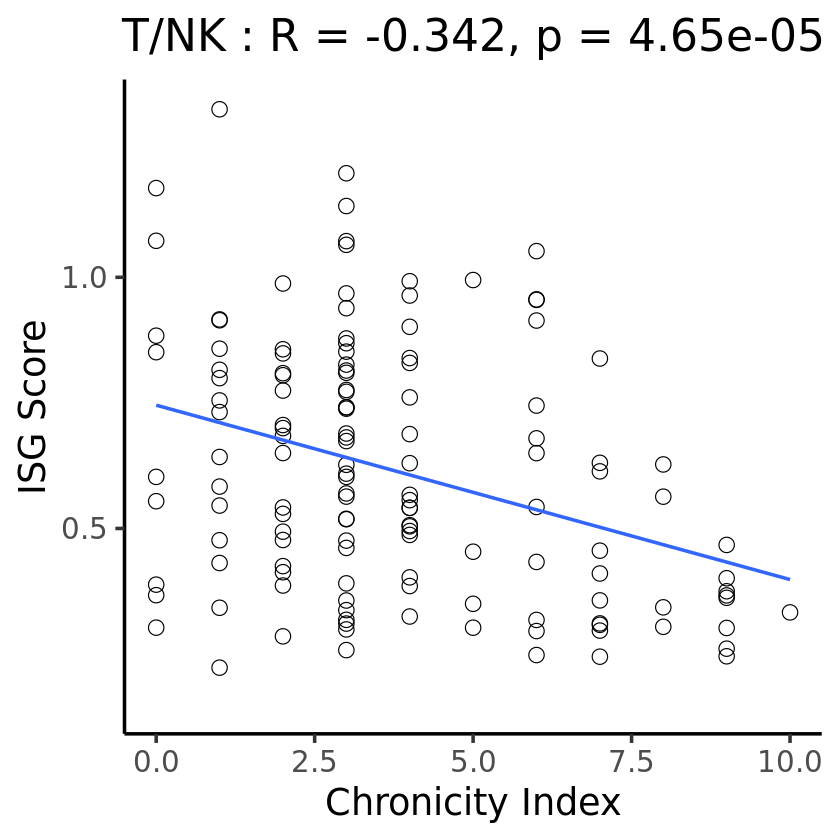

In [6]:
p1 <- ggplot(chron_isg_pb, 
           aes(x = Final_Chronicity, y = isg_score)) +
    geom_point(shape = 21, size = 4) + 
    theme_classic(base_size = 22) + 
    geom_smooth(method = 'lm', se = FALSE) + 
    labs(x = 'Chronicity Index', 
         y = 'ISG Score',
         title = 'T/NK : R = -0.342, p = 4.65e-05') + 
    theme(plot.title = element_text(hjust = 0.5),
          text=element_text(family="Arial"))
p1

In [13]:
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/tnk_isg_score.png",
       p1,
       base_height = 10,
       base_width = 10)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 42 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 42 rows containing missing values (`geom_point()`).”


### Activity

In [381]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Activity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/activity/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/activity/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/activity/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [382]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Activity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/activity/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/activity/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/activity/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


### ISN

In [383]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_ISN)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/ISN/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/ISN/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/ISN/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [385]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_ISN)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/ISN/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/ISN/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/ISN/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


### % Injured PT

In [14]:
lateinjury_high_prop <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/injured_pt_highprop_singlecell_05102024.rds') %>% 
                            select(Prop, sample)

In [15]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('hUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

meta <- meta %>% left_join(lateinjury_high_prop %>% rename(injured_pt_prop = Prop))

ind <- c(1:nrow(meta))[!is.na(meta$injured_pt_prop)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)


meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "sample"
Joining, by = "Responder.Status"


Joining, by = "individual"



Call:
lm(formula = Final_Chronicity ~ injured_pt_prop, data = pt_chron)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.0845 -1.2206 -0.0351  1.1120  5.6398 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)      1.42868    0.29767   4.800 4.03e-06 ***
injured_pt_prop  0.25735    0.02771   9.289 2.73e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.92 on 140 degrees of freedom
Multiple R-squared:  0.3813,	Adjusted R-squared:  0.3769 
F-statistic: 86.28 on 1 and 140 DF,  p-value: 2.73e-16


`geom_smooth()` using formula = 'y ~ x'


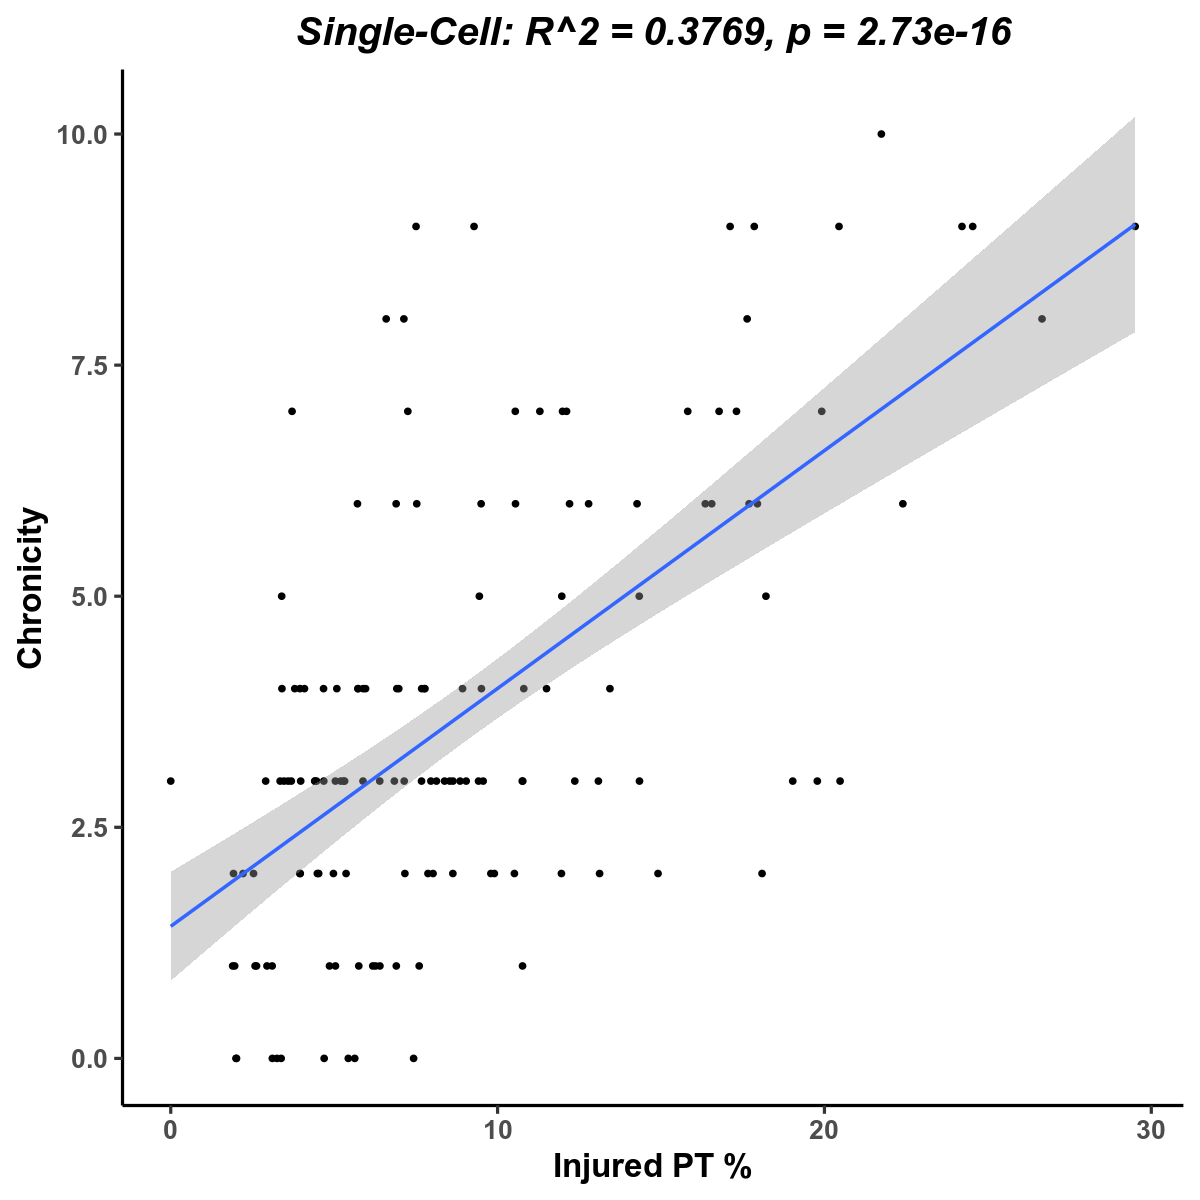

In [33]:
pt_chron <- sc_pt_meta %>%                         
                        mutate(individual = str_split(sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical %>% select(individual, Final_Chronicity)) %>% na.omit()

summary(lm(Final_Chronicity ~ injured_pt_prop, data = pt_chron))

fig.size(10, 10)
ggplot(pt_chron, aes(x = injured_pt_prop, y = Final_Chronicity)) + 
    geom_point() + 
    theme_classic(base_size = 20) +
    geom_smooth(method = "lm") + 
    labs(x = "Injured PT %", y = "Chronicity", title = "Single-Cell: R^2 = 0.3769, p = 2.73e-16") + 
    theme(plot.title = element_text(hjust = 0.5, face= "bold.italic"),
          axis.text = element_text(face = "bold"),
          axis.title = element_text(face = "bold"))

Joining, by = "individual"



Call:
lm(formula = Final_Chronicity ~ injured_pt_prop, data = pt_chron)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.1271 -1.3424 -0.2293  0.7517  5.4168 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)      1.12537    0.72786   1.546    0.132    
injured_pt_prop  0.30708    0.06422   4.782  3.5e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.018 on 33 degrees of freedom
Multiple R-squared:  0.4093,	Adjusted R-squared:  0.3914 
F-statistic: 22.87 on 1 and 33 DF,  p-value: 3.501e-05


`geom_smooth()` using formula = 'y ~ x'


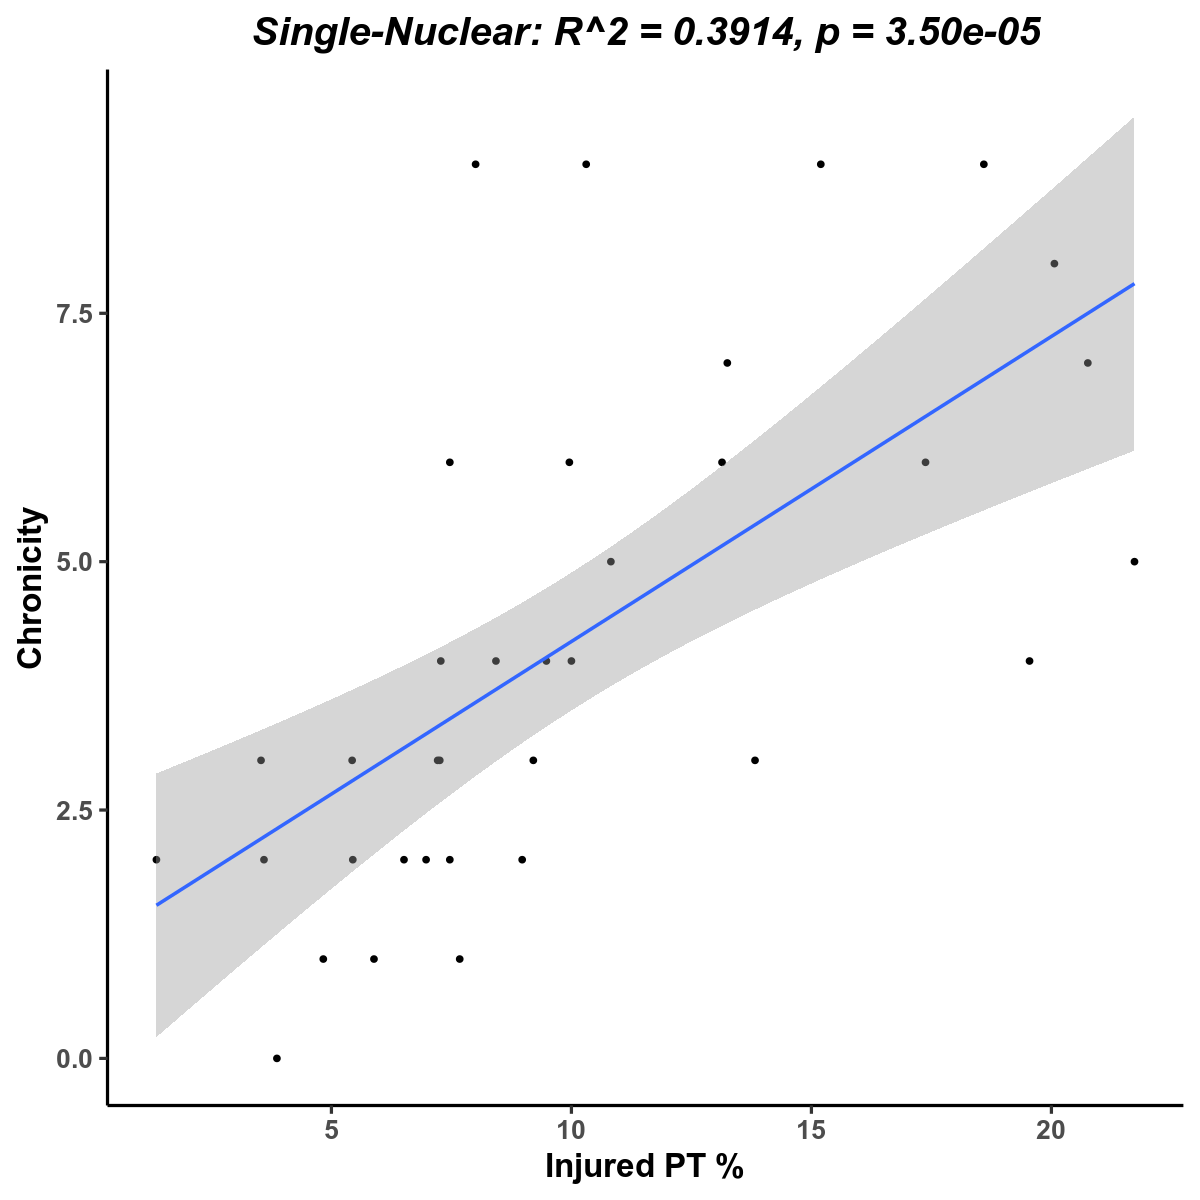

In [36]:
sn_pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/sn_injured_pt_prop_07142023.rds')
pt_chron <- sn_pt_meta %>%                         
                        mutate(individual = str_split(sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical %>% select(individual, Final_Chronicity)) %>% na.omit()

summary(lm(Final_Chronicity ~ injured_pt_prop, data = pt_chron))

fig.size(10, 10)
ggplot(pt_chron, aes(x = injured_pt_prop, y = Final_Chronicity)) + 
    geom_point() + 
    theme_classic(base_size = 20) +
    geom_smooth(method = "lm") + 
    labs(x = "Injured PT %", y = "Chronicity", 
         title = "Single-Nuclear: R^2 = 0.3914, p = 3.50e-05") + 
    theme(plot.title = element_text(hjust = 0.5, face= "bold.italic"),
          axis.text = element_text(face = "bold"),
          axis.title = element_text(face = "bold"))

#### RESULTS

#### CNA

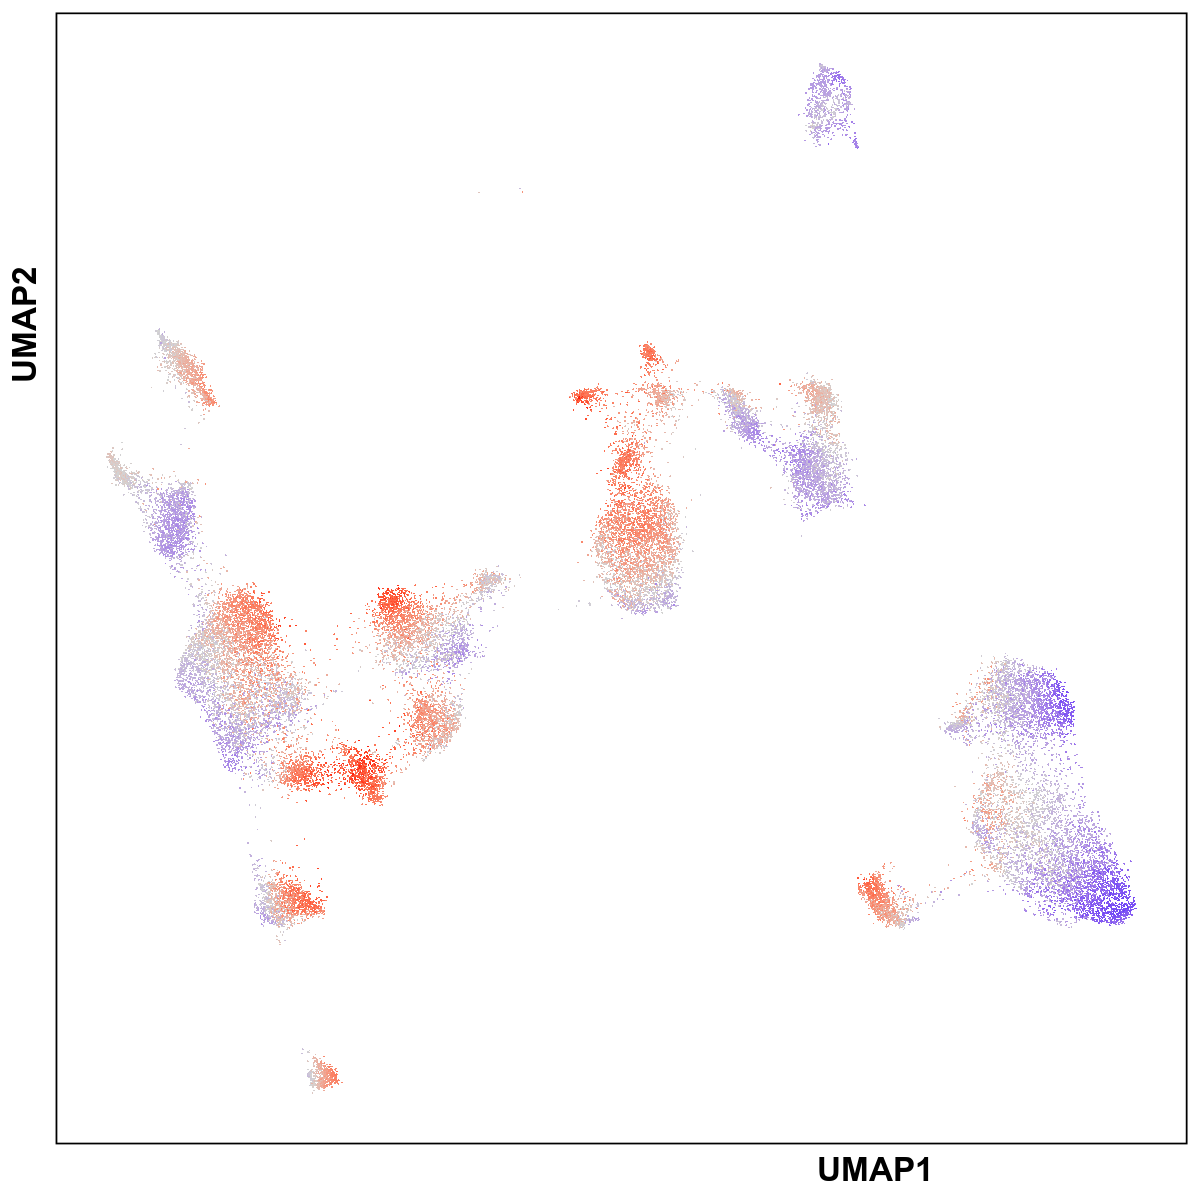

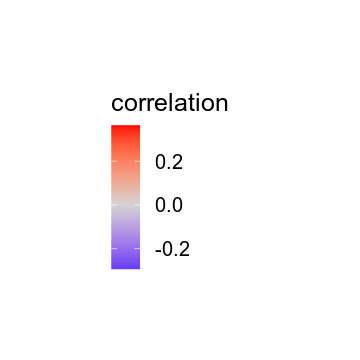

In [3]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_ncorr_cond_nochron.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_fdrs_cond_nochron.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure9/figure9i-cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure9/figure9i-cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)
options(warn=0)

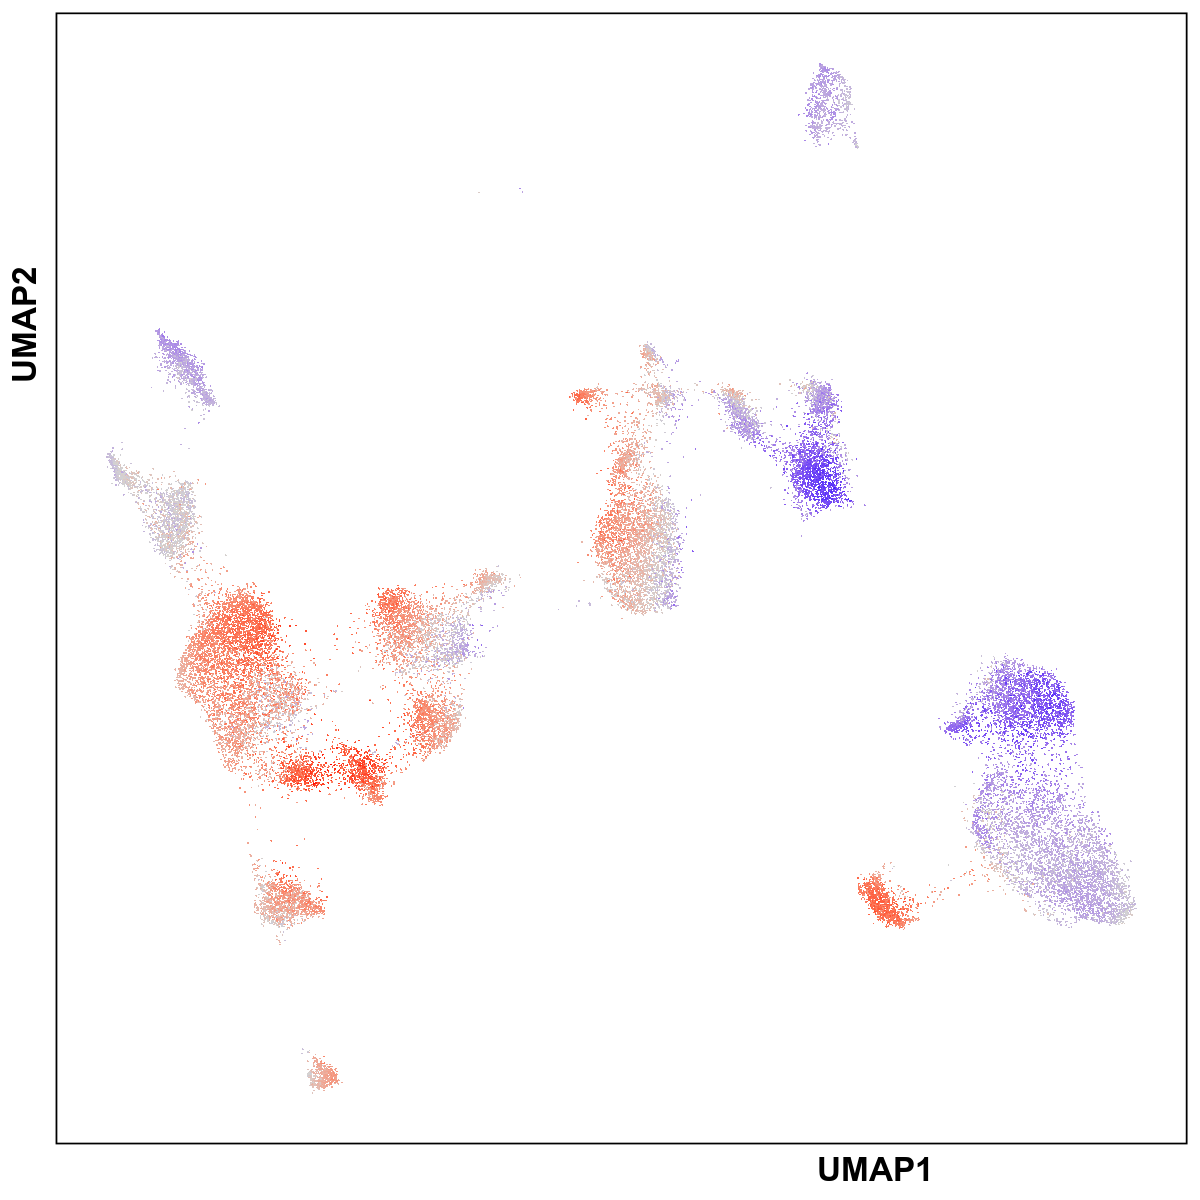

In [ ]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure6/figure6a-cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure6/figure6a-cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)
options(warn=0)

#### PER CELL Chronicity vs Injured PT

In [6]:
pt_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_ncorr_cond_nochron.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_fdrs_cond_nochron.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
pt_meta$ncorr <- ncorr$V1

meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

ncorr_meta <- pt_meta %>% 
                    select(cell, ncorr) %>% 
                    rename(pt_ncorr = ncorr) %>% 
                left_join(meta %>% 
                            select(cell, ncorr) %>% 
                            rename(chronicity_ncorr = ncorr)) %>% na.omit()

Joining, by = "cell"


In [8]:
fig.size(8, 9)
cor(ncorr_meta$pt_ncorr, ncorr_meta$chronicity_ncorr)
cor_plot <- ggplot(ncorr_meta, aes(x = pt_ncorr, y = chronicity_ncorr)) +
                    geom_bin2d(bins = 50) +
                    scale_fill_continuous(type = "viridis",
                                          breaks = c(50, 150, 250, 350)) +
                   theme_classic(base_size = 25) +
                    geom_abline(linetype = 'dashed', linewidth = 2) + 
                    scale_x_continuous(limits = c(-0.4, 0.4)) + 
                    scale_y_continuous(limits = c(-0.4, 0.4)) + 
                    labs(x = "Injured PT CNA correlation",
                         y = "Chronicity CNA correlation",
                         title = "T/NK: R = 0.700") + 
                    theme(
                          plot.title = element_text(size = 30, 
                                                    hjust = 0.5),
                            text=element_text(family="Arial"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure9/figure9i.png",
       cor_plot,
       base_height = 8,
       base_width = 9)

[1] 0.7003926

In [5]:
pt_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
pt_meta$ncorr <- ncorr$V1

meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

ncorr_meta <- pt_meta %>% 
                    select(cell, ncorr) %>% 
                    rename(pt_ncorr = ncorr) %>% 
                left_join(meta %>% 
                            select(cell, ncorr) %>% 
                            rename(chronicity_ncorr = ncorr)) %>% na.omit()

Joining, by = "cell"


In [29]:
fig.size(8, 9)
cor(ncorr_meta$pt_ncorr, ncorr_meta$chronicity_ncorr)
cor_plot <- ggplot(ncorr_meta, aes(x = pt_ncorr, y = chronicity_ncorr)) +
                    geom_bin2d(bins = 50) +
                    scale_fill_continuous(type = "viridis",
                                          breaks = c(50, 150, 250, 350)) +
                   theme_classic(base_size = 25) +
                    geom_abline(linetype = 'dashed', linewidth = 2) + 
                    scale_x_continuous(limits = c(-0.4, 0.4)) + 
                    scale_y_continuous(limits = c(-0.4, 0.4)) + 
                    labs(x = "Injured PT CNA correlation",
                         y = "Chronicity CNA correlation",
                         title = "T/NK: R = 0.986") + 
                    theme(
                          plot.title = element_text(size = 30, 
                                                    hjust = 0.5),
                            text=element_text(family="Arial"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure9/figure9i.png",
       cor_plot,
       base_height = 8,
       base_width = 9)

[1] 0.9862325

#### MASC

In [10]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')
tnk_rawcounts <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_rawcounts_03062023.rds')
mito_genes_subset <- c("MT-ND5", "MT-ND6")
percent_mito <- colSums(tnk_rawcounts[mito_genes_subset, ]) / colSums(tnk_rawcounts) * 100
percent_mito <- data.frame(cell = names(percent_mito), percent.mt = percent_mito)
qcd_meta <- left_join(qcd_meta, percent_mito)

meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/t_nk/injured_pt/sc_meta.csv')


model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "injured_pt_prop",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", 
                                  "percent.mt",
                                  'Final_Site_JHU',
                                  'Final_Site_NYU',
                                  'First_biop',
                                  'Responder_Status',
                                  'Age'),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/injured_pt_cond_nochron.rds')

Joining, by = "cell"
Joining, by = "cell"
Using null model: cluster ~ nCount_RNA + percent.mt + Final_Site_JHU + Final_Site_NYU + First_biop + Responder_Status + Age + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Creating logistic mixed models for cluster19

Creating logistic mixed models for cluster2

Creating logistic mixed models for cluster20

Creating logistic mixed models for cluster21

Creating logistic mixed models for cluster3

Creating logistic mixed models for cluster4

Creating logistic mixed models for cluster5

Warning message:
“Removed 20 rows containing missing values (`geom_label_repel()`).”
Warning message:
“Removed 20 rows containing missing values (`geom_label_repel()`).”


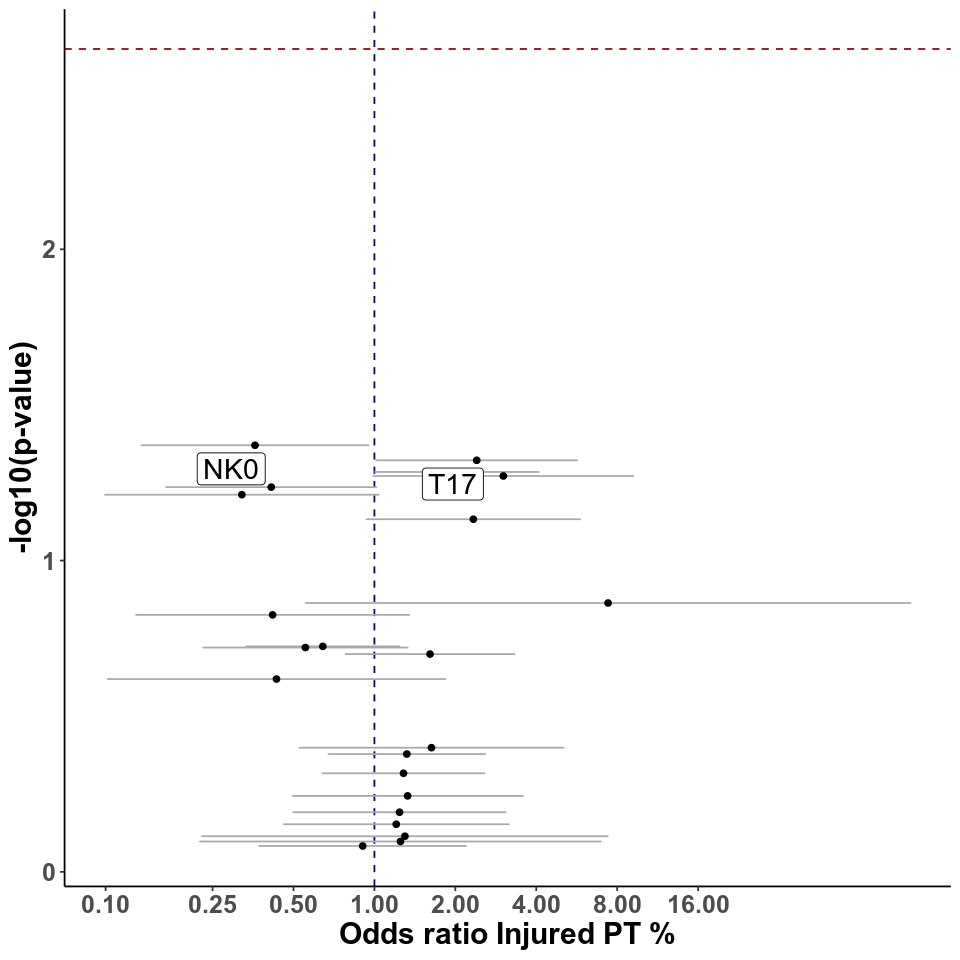

In [15]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/injured_pt_cond_nochron.rds')

res <- res %>% 
        rowwise() %>% 
        mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(0, 3), 
                                paste0('NK', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('T', unlist(str_split(cluster, 'cluster'))[2])))

fig.size(8, 8)
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
       aes(x = injured_pt_prop.OR, y = -log10(model.pvalue))) +
    theme_classic() + ylab("-log10(p-value)") + xlab("Odds ratio Injured PT %") +
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=injured_pt_prop.OR.95pct.ci.lower, 
                      xmax=injured_pt_prop.OR.95pct.ci.upper), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.01, 0.1, 0.25, 0.5, 1, 2, 4, 8, 16)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6) +
    theme(axis.title = element_text(size = 18, face = "bold"),
          axis.text = element_text(size = 15, face = "bold"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure9/figure9k-masc.png",
       masc_plot,
       base_height = 8,
       base_width = 8)
masc_plot

In [54]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/injured_pt.rds')

Warning message:
“Removed 21 rows containing missing values (`geom_label_repel()`).”


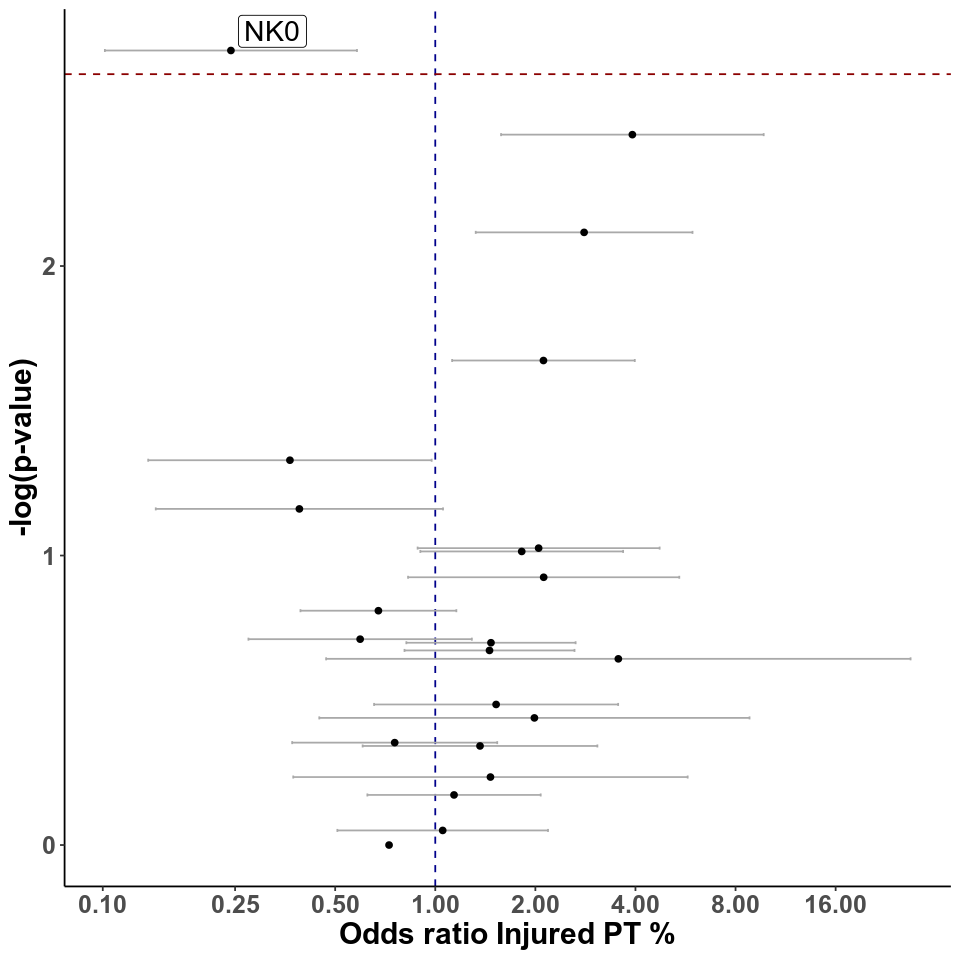

In [55]:
fig.size(8, 8)
ggplot(data = res %>% 
                   mutate(label = ifelse(pvalue < 0.05, cluster, NA)), 
       aes(x = injured_pt_prop.OR, y = -log10(model.pvalue))) +
    theme_classic() + ylab("-log(p-value)") + xlab("Odds ratio Injured PT %") +
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=injured_pt_prop.OR.95pct.ci.lower, 
                      xmax=injured_pt_prop.OR.95pct.ci.upper), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(0.05/23), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.01, 0.1, 0.25, 0.5, 1, 2, 4, 8, 16)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6) +
    theme(axis.title = element_text(size = 18, face = "bold"),
          axis.text = element_text(size = 15, face = "bold"))

In [2]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/t_nk/injured_pt_cond.rds')

In [3]:
res

,cluster,size,model.pvalue,injured_pt_prop.OR,injured_pt_prop.OR.95pct.ci.lower,injured_pt_prop.OR.95pct.ci.upper,bonferroni
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cluster0,cluster0,4640,0.04260704,0.3595766,0.13584525,0.9517841,0.9373549
cluster17,cluster17,1342,0.04762197,2.4026453,1.01588271,5.6824518,1.0000000
cluster13,cluster13,1209,0.05191543,2.0281852,1.00451997,4.0950258,1.0000000
cluster18,cluster18,5543,0.05348585,3.0173778,0.99007615,9.1958270,1.0000000
cluster20,cluster20,1485,0.05808098,0.4133799,0.16795959,1.0174052,1.0000000
cluster2,cluster2,373,0.06142166,0.3212604,0.09938021,1.0385193,1.0000000
cluster15,cluster15,1666,0.07363568,2.3335729,0.93363352,5.8326555,1.0000000
cluster4,cluster4,839,0.13684071,7.3990116,0.55441741,98.7439641,1.0000000
cluster1,cluster1,2306,0.14941615,0.4181608,0.12961189,1.3490928,1.0000000
